# Packages and data

## Calling in necessary packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import seaborn as sns
import itertools
import math
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.transforms as transforms

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter, NullFormatter, NullLocator

from scipy.stats import gaussian_kde
from scipy import stats
from scipy.stats import linregress
from scipy.stats import shapiro, ks_2samp, levene, ttest_ind, mannwhitneyu

from pyproj import Transformer

from adjustText import adjust_text

In [2]:
!pip install pyproj
!pip install adjustText
!pip install tabulate

## Calling in data

In [3]:
df = pd.read_csv("AvulsionAngles.csv")
df2 = pd.read_csv("Profiles.csv")
df3 = pd.read_csv("Fan Widths.csv")
df4 = pd.read_csv("Fan Morphometrics.csv")

## Defining fan groups

In [4]:
FAN_GROUPS = {
    "Subgroup 1a": ["Ili", "Abrisham", "Niger"],
    "Subgroup 1b": ["Saskatchewan", "Shire", "Okavango"],
    "Subgroup 2a": ["Canning", "Karnali", "Kosi", "Manas"],
    "Subgroup 2b": ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]
}

GROUP_COLORS = {
    "Subgroup 1a": "#FFD700",
    "Subgroup 1b": "#B22222",
    "Subgroup 2a": "#3CB371",
    "Subgroup 2b": "#00CED1"
}

def assign_group(fan_name):
    """Maps individual fan sites to their respective subgroups."""
    for group, fans in FAN_GROUPS.items():
        if fan_name in fans:
            return group
    return np.nan

# Apply classification to main DataFrames
for frame in [df, df2]:
    if "Fan" in frame.columns:
        frame["Group"] = frame["Fan"].apply(assign_group)

g1a = df[df["Group"] == "Subgroup 1a"].copy()
g1b = df[df["Group"] == "Subgroup 1b"].copy()
g2a = df[df["Group"] == "Subgroup 2a"].copy()
g2b = df[df["Group"] == "Subgroup 2b"].copy()

# Figure 1

## Fig. 1a: Point clouds

In [5]:
# Haversine funciton
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculates the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    R = 6371000  # Radius of Earth in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = (np.sin(delta_phi/2.0)**2 + 
         np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Reference Coordinates (From Hartley et al. 2010 or adjusted)
site_coords = {
    "Abrisham":        {"apex": (35.6157, 56.2550),  "toe": (35.4078, 55.9442)},
    "Canning":         {"apex": (69.8510, -146.461), "toe": (70.0777, -145.8116)},
    "Cusay":           {"apex": (6.6916, -71.8411),  "toe": (6.7016, -71.1415)},
    "Ili":             {"apex": (44.8170, 76.2228),  "toe": (46.5799, 75.4268)},
    "Karnali":         {"apex": (28.6107, 81.2745),  "toe": (28.2730, 81.0855)},
    "Kosi":            {"apex": (26.5300, 86.9380),  "toe": (25.4124, 87.2552)},
    "Manas":           {"apex": (26.7828, 90.9551),  "toe": (26.2502, 90.8177)},
    "Niger":           {"apex": (14.1386, -5.0244),  "toe": (15.2973, -3.9710)},
    "Nomhon He":       {"apex": (36.2090, 96.3850),  "toe": (36.5691, 96.4678)},
    "Okavango":        {"apex": (-18.858, 22.3820),  "toe": (-19.2357, 23.9333)},
    "Rud-i-Shur Tabas": {"apex": (32.7000, 60.5464), "toe": (32.6369, 60.8884)},
    "Saskatchewan":    {"apex": (53.7075, -103.2286),"toe": (54.0362, -102.5203)},
    "Shire":           {"apex": (-16.2056, 34.9333), "toe": (-16.5489, 35.1235)}
}

# Optional: If you prefer keeping the original dictionaries for your existing code:
apex_coords = {k: v["apex"] for k, v in site_coords.items()}
toe_coords = {k: v["toe"] for k, v in site_coords.items()}

C:\Users\lukej\AppData\Local\Temp\ipykernel_41080\785967201.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apex_rows['dist_to_true_apex'] = np.sqrt(
C:\Users\lukej\AppData\Local\Temp\ipykernel_41080\785967201.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apex_rows['dist_to_true_apex'] = np.sqrt(
C:\Users\lukej\AppData\Local\Temp\ipykernel_41080\785967201.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

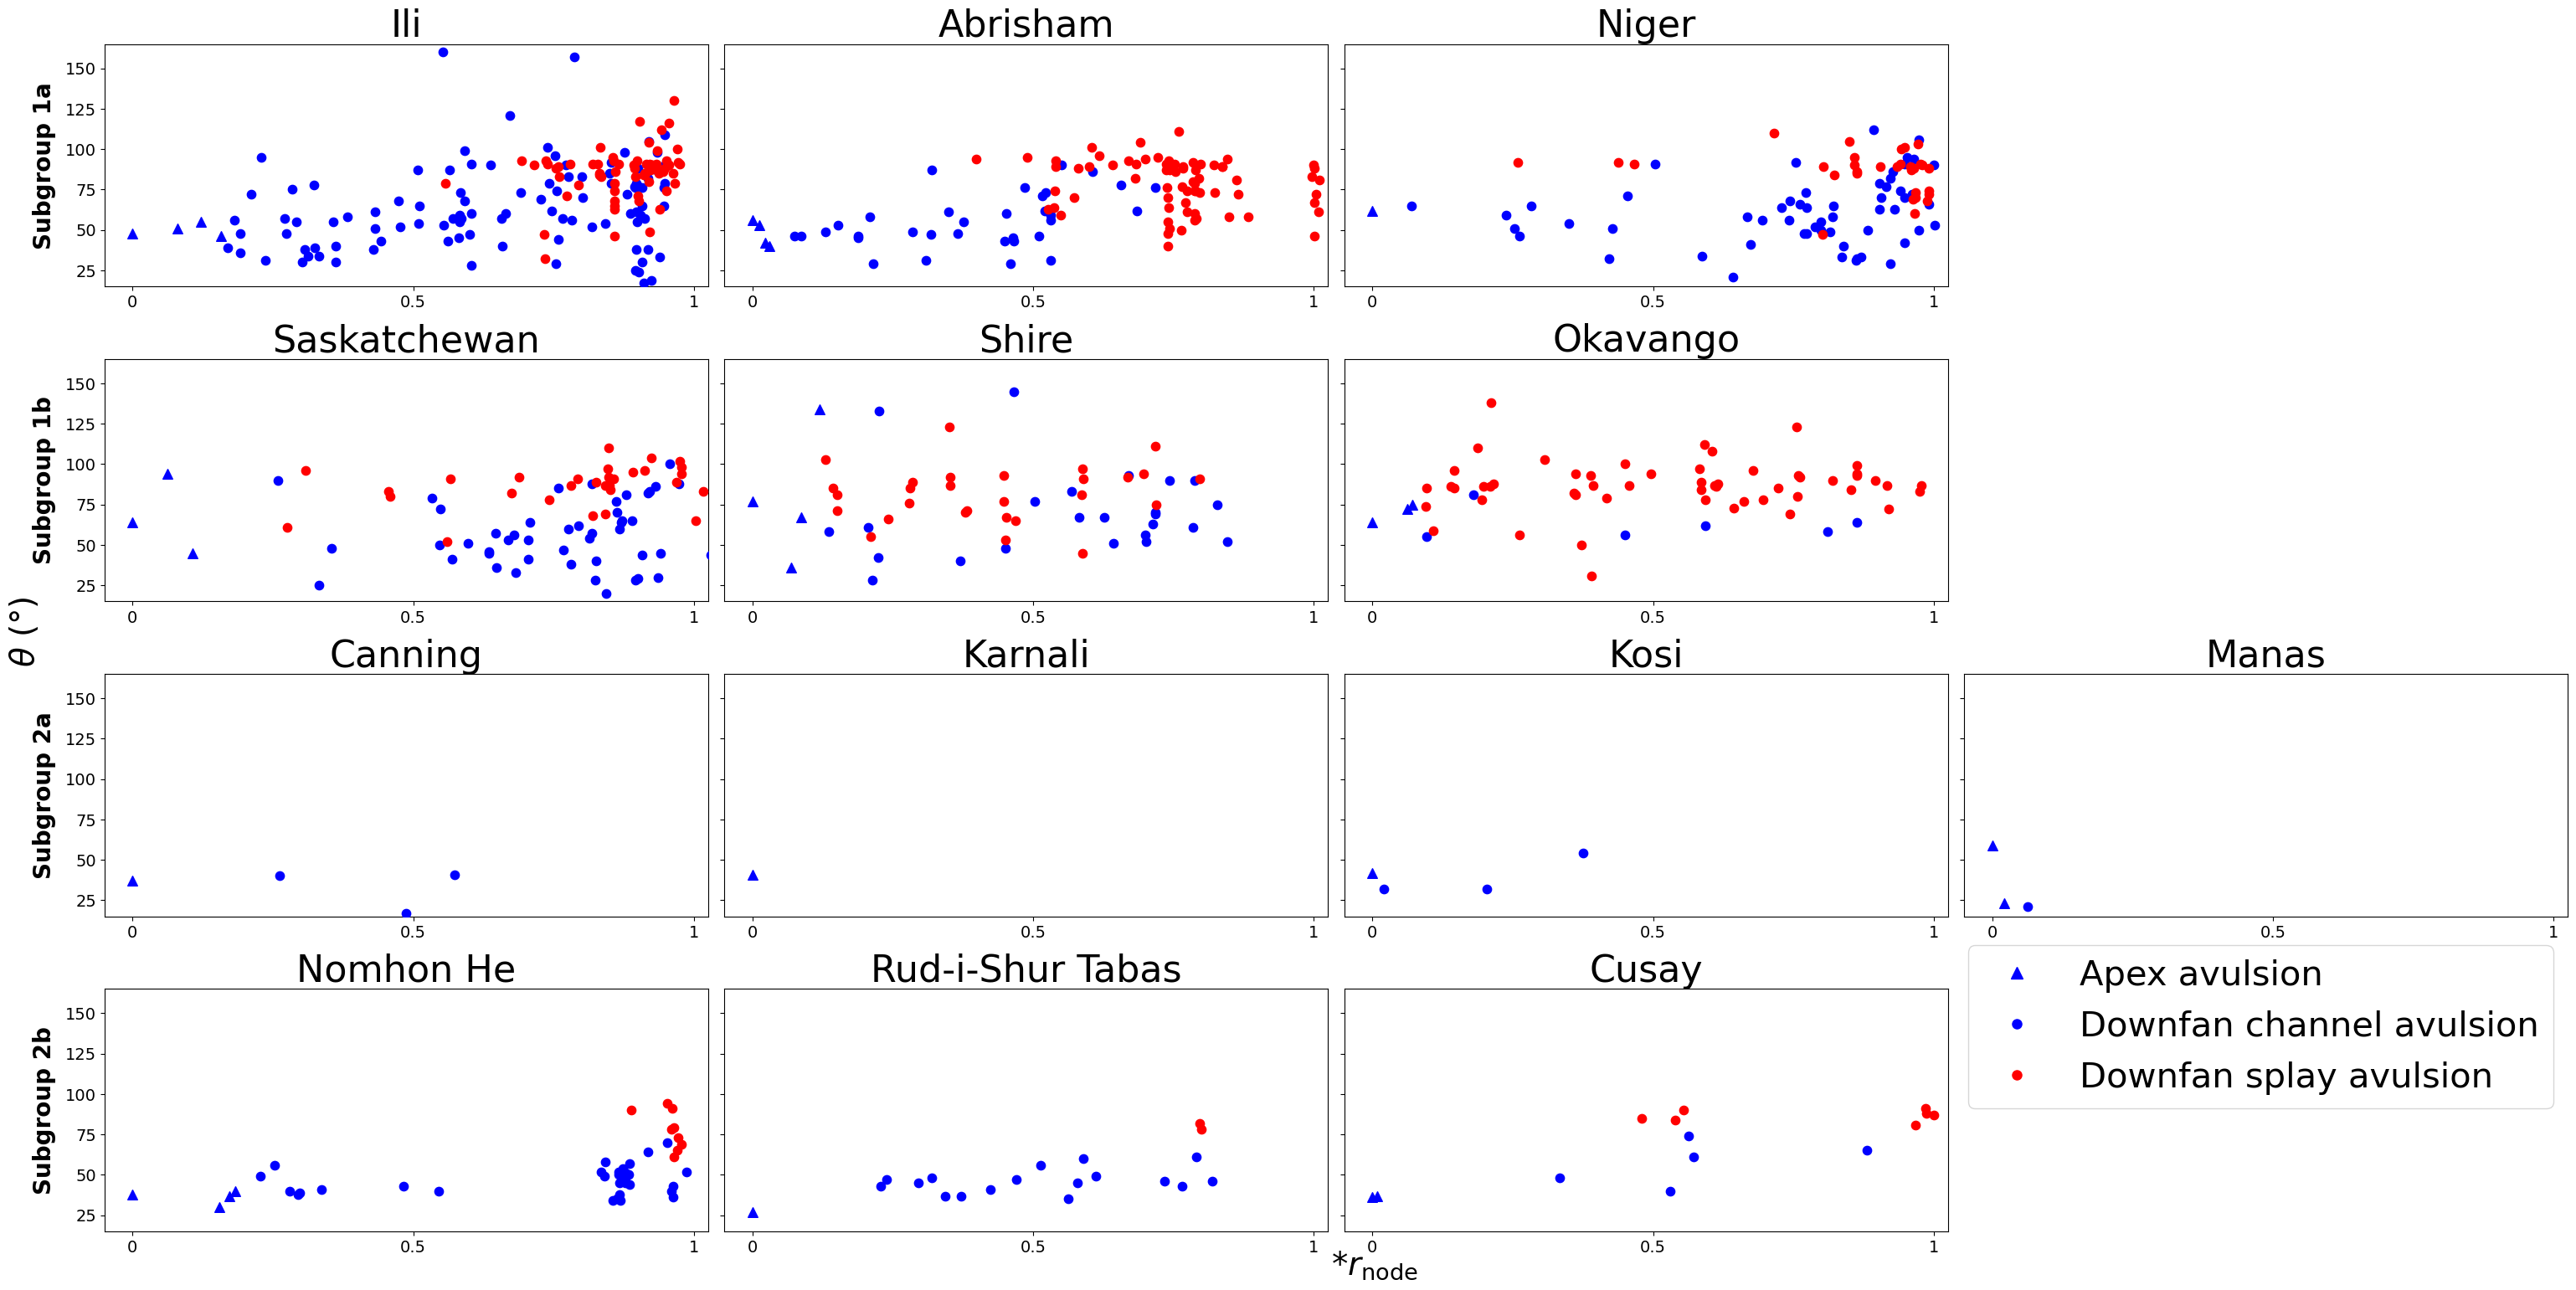

In [10]:
# CLEAN AND NORMALIZE DATA (The "Point Cloud" Logic)
df['Apex'] = df['Apex'].astype(str).str.strip()
df['Crevasse'] = df['Crevasse'].astype(str).str.strip()
df['Angle'] = pd.to_numeric(df['Angle'], errors='coerce')

ref_apex_index = {}
df['Distance_m'] = np.nan
df['Distance_norm'] = np.nan

for fan in df['Fan'].unique():
    if fan not in apex_coords or fan not in toe_coords:
        continue

    apex_lat, apex_lon = apex_coords[fan]
    toe_lat, toe_lon = toe_coords[fan]
    total_dist = haversine(apex_lat, apex_lon, toe_lat, toe_lon)

    fan_rows = df[df['Fan'] == fan].copy()
    apex_rows = fan_rows[fan_rows['Apex'] == 'Yes']

    # Correction logic to find the true apex row
    if len(apex_rows) > 0:
        apex_rows['dist_to_true_apex'] = np.sqrt(
            (apex_rows['Latitude'] - apex_lat) ** 2 +
            (apex_rows['Longitude'] - apex_lon) ** 2
        )
        ref_apex_index[fan] = apex_rows.loc[apex_rows['dist_to_true_apex'].idxmin()].name
    else:
        ref_apex_index[fan] = None

    # Calculate and Normalize distances
    fan_mask = df['Fan'] == fan
    df.loc[fan_mask, 'Distance_m'] = df.loc[fan_mask].apply(
        lambda row: haversine(apex_lat, apex_lon, row['Latitude'], row['Longitude']),
        axis=1
    )

    if total_dist != 0:
        df.loc[fan_mask, 'Distance_norm'] = df.loc[fan_mask, 'Distance_m'] / total_dist

    if ref_apex_index[fan] is not None:
        df.loc[ref_apex_index[fan], 'Distance_norm'] = 0

# PLOT USING YOUR SPECIFIC VISUAL STYLE
n_rows = len(FAN_GROUPS)
n_cols = max(len(fans) for fans in FAN_GROUPS.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(32, n_rows * 4), sharey=True)

for row_idx, (group_label, fans) in enumerate(FAN_GROUPS.items()):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        
        if col_idx < len(fans):
            fan = fans[col_idx]
            fan_data = df[df['Fan'] == fan]
            
            if not fan_data.empty:
                # --- Plotting Logic (Original Color/Size Logic) ---
                apex_points = fan_data[fan_data['Apex'] == 'Yes']
                ax.scatter(apex_points['Distance_norm'], apex_points['Angle'],
                           c='blue', marker='^', s=70, zorder=5)

                downfan_points = fan_data[fan_data['Apex'] == 'No']
                if not downfan_points.empty:
                    crev_no = downfan_points[downfan_points['Crevasse'] == 'No']
                    crev_yes = downfan_points[downfan_points['Crevasse'] == 'Yes']
                    ax.scatter(crev_no['Distance_norm'], crev_no['Angle'],
                               c='blue', marker='o', s=55, zorder=4)
                    ax.scatter(crev_yes['Distance_norm'], crev_yes['Angle'],
                               c='red', marker='o', s=55, zorder=4)

                # --- Individual Axis Styling (Matches Your Request) ---
                ax.set_title(fan, fontsize=32)
                ax.set_xlim(-0.05, 1.025)
                ax.set_ylim(15, 165)
                ax.grid(False)
                ax.set_xticks([0, 0.5, 1])
                ax.set_xticklabels(['0', '0.5', '1'], fontsize=14)
                ax.tick_params(axis='y', labelsize=14)
                
                if col_idx == 0:
                    ax.annotate(group_label, xy=(-0.1, 0.5), xycoords='axes fraction',
                                rotation=90, ha='center', va='center', 
                                fontsize=20, fontweight='bold')
            else:
                ax.axis('off')
        else:
            ax.axis('off')

# LEGEND
legend_elements = [
    Line2D([0], [0], marker='^', color='blue', linestyle='None', markersize=10, label='Apex avulsion'),
    Line2D([0], [0], marker='o', color='blue', linestyle='None', markersize=8, label='Downfan channel avulsion'),
    Line2D([0], [0], marker='o', color='red', linestyle='None', markersize=8, label='Downfan splay avulsion')
]

fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.715, 0.18),
    frameon=True,
    fontsize=30
)

# Global axis labels (Original formatting)
fig.text(0.5, -0.005, r'$*r_{\mathrm{node}}$', ha='center', fontsize=28)
fig.text(-0.01, 0.475, r'$\theta$ (°)', va='center', rotation='vertical', fontsize=28)

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

# Figure 2

## Figure 2a: Violin plot of all angles

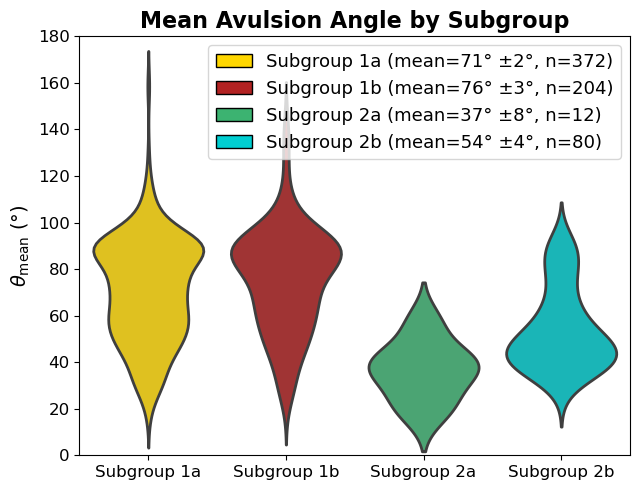

In [11]:
# 1. Plot configuration
title_all = "Mean Avulsion Angle by Subgroup"
y_label = r"$\theta_{\mathrm{mean}}\ (°)$"
order = ["Subgroup 1a", "Subgroup 1b", "Subgroup 2a", "Subgroup 2b"]

# Filter data and set categorical order for plotting
df_plot_all = df[df["Group"].isin(order)].copy()
df_plot_all["Group"] = pd.Categorical(df_plot_all["Group"], categories=order, ordered=True)

# Formatting constants
title_font, label_font, tick_font, legend_font = 16, 14, 12, 13

# 2. Generate Violin Plot
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    x="Group",
    y="Angle",
    hue="Group",           
    legend=False,          
    data=df_plot_all,
    order=order,
    palette=GROUP_COLORS,  
    linewidth=2,
    inner=None
)

# 3. Calculate statistics for legend
grouped_all = df_plot_all.groupby("Group", observed=False)["Angle"]
means_all = grouped_all.mean()
counts_all = grouped_all.count()

legend_elements = []

for g in order:
    xdata = df_plot_all.loc[df_plot_all["Group"] == g, "Angle"].dropna()
    n = len(xdata)
    
    if n > 1:
        # 95% Confidence Interval calculation
        ci_low, ci_high = stats.t.interval(
            0.95, n - 1, loc=means_all[g], scale=stats.sem(xdata)
        )
        ci_half = round(ci_high - means_all[g])
    else:
        ci_half = 0
    
    label = f"{g} (mean={round(means_all[g])}° ±{ci_half}°, n={int(counts_all[g])})"
    legend_elements.append(Patch(facecolor=GROUP_COLORS[g], edgecolor="k", label=label))

# 4. Final layout and labels
ax.legend(handles=legend_elements, fontsize=legend_font, loc="upper right", frameon=True)
ax.set_title(title_all, fontsize=title_font, fontweight='bold')
ax.set_xlabel("", fontsize=label_font) 
ax.set_ylabel(y_label, fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()

## Fig. 2b: Apex angles box plots

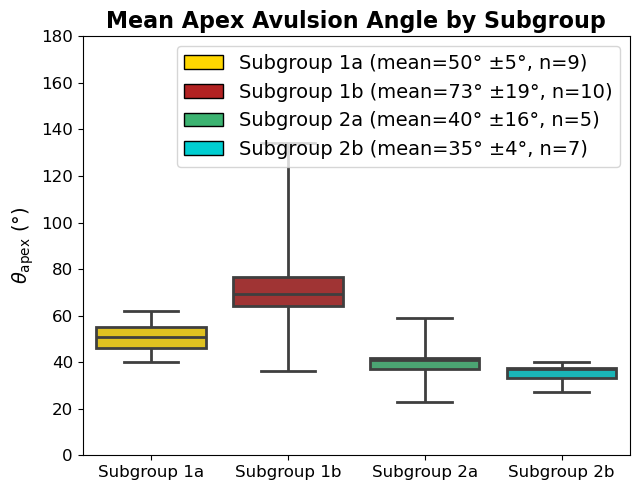

In [12]:
# 1. Plot configuration (Apex nodes only)
order = ["Subgroup 1a", "Subgroup 1b", "Subgroup 2a", "Subgroup 2b"]
y_label = r"$\theta_{\mathrm{apex}}$ (°)"
title_all = "Mean Apex Avulsion Angle by Subgroup"

# Filter specifically for apex avulsions and set categorical order
df_plot_apex = df[(df["Group"].isin(order)) & (df["Apex"] == "Yes")].copy()
df_plot_apex["Group"] = pd.Categorical(df_plot_apex["Group"], categories=order, ordered=True)

# Formatting constants
title_font, label_font, tick_font, legend_font = 16, 14, 12, 14

# 2. Generate Boxplot
plt.figure(figsize=(6.5, 5))
ax = sns.boxplot(
    x="Group",
    y="Angle",
    hue="Group",
    legend=False,
    data=df_plot_apex,
    order=order,
    palette=GROUP_COLORS,
    showfliers=False,
    linewidth=2,
    whis=[0, 100]
)

# 3. Statistical Calculations for Legend
# observed=False handles categorical grouping warnings
grouped_apex = df_plot_apex.groupby("Group", observed=False)["Angle"]
means_apex = grouped_apex.mean()
counts_apex = grouped_apex.count()

legend_elements = []

for g in order:
    xdata = df_plot_apex.loc[df_plot_apex["Group"] == g, "Angle"].dropna()
    n = len(xdata)
    
    if n > 1:
        # 95% Confidence Interval
        ci_low, ci_high = stats.t.interval(
            0.95, n - 1, loc=means_apex[g], scale=stats.sem(xdata)
        )
        ci_half = round(ci_high - means_apex[g])
    else:
        ci_half = 0
    
    label = f"{g} (mean={round(means_apex[g])}° ±{ci_half}°, n={int(counts_apex[g])})"
    legend_elements.append(Patch(facecolor=GROUP_COLORS[g], edgecolor="k", label=label))

# 4. Final layout and labels
ax.legend(handles=legend_elements, fontsize=legend_font, loc="upper right", frameon=True)
ax.set_title(title_all, fontsize=title_font, fontweight='bold')
ax.set_xlabel("", fontsize=label_font)
ax.set_ylabel(y_label, fontsize=label_font)
ax.tick_params(axis="both", labelsize=tick_font)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()

## Fig. 2c-f: Subgroup violin plots

In [13]:
# Shared Condition Configuration
CONDITION_ORDER = ["Apex", "All Channel", "Downfan", "Splays"]
DEFAULT_CONDITION_COLORS = {
    "All Channel": "skyblue",
    "Downfan": "royalblue",
    "Splays": "tomato",
}

LABEL_MAP = {
    "Apex": r"$\theta_{\mathrm{apex}}$",
    "All Channel": r"$\theta_{\mathrm{all\_channel}}$",
    "Downfan": r"$\theta_{\mathrm{d\_channel}}$",
    "Splays": r"$\theta_{\mathrm{splay}}$",
}

# Universal Font Sizes
TITLE_FONT, LABEL_FONT, TICK_FONT, LEGEND_FONT = 16, 14, 12, 13

# Helper function to categorize data and prepare for plotting
def prepare_combined_data(df, group_name):
    df_sub = df[df["Group"] == group_name].copy()
    
    # Condition masks
    condition_map = {
        "Apex": df_sub["Apex"] == "Yes",
        "All Channel": df_sub["Crevasse"] == "No",
        "Downfan": (df_sub["Apex"] == "No") & (df_sub["Crevasse"] == "No"),
        "Splays": df_sub["Crevasse"] == "Yes"
    }
    
    df_list = []
    for cond, mask in condition_map.items():
        temp = df_sub[mask].copy()
        temp["Condition"] = cond
        df_list.append(temp)
    
    combined = pd.concat(df_list, ignore_index=True)
    combined["Condition"] = pd.Categorical(
        combined["Condition"], categories=CONDITION_ORDER, ordered=True
    )
    return combined

# Fig. 2c: Subgroup 1a violin plots

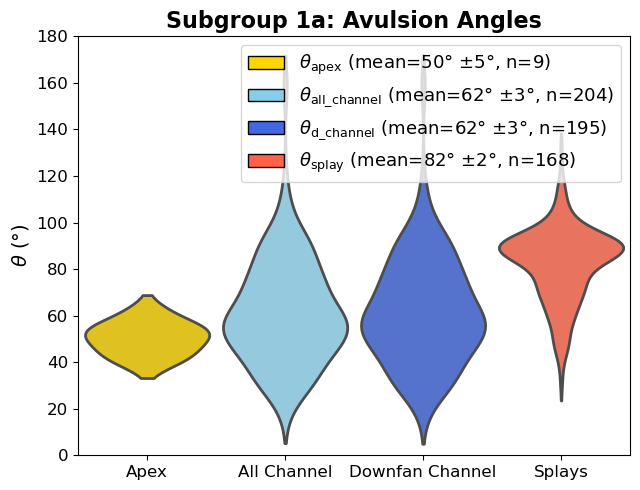

In [14]:
# 1. Group-specific settings
group_name = "Subgroup 1a"
apex_color = "#FFD700" 
palette = {"Apex": apex_color, **DEFAULT_CONDITION_COLORS}

# 2. Process data using the global helper function
df_plot = prepare_combined_data(df, group_name)

# 3. Generate Violin Plot
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    data=df_plot, 
    x="Condition", 
    y="Angle", 
    hue="Condition", # Fixes palette FutureWarning
    palette=palette, 
    linewidth=2, 
    inner=None, 
    cut=1.5, 
    width=0.9,
    legend=False     # Fixes palette FutureWarning
)

# 4. Statistical legend (Mean ± 95% CI)
legend_elements = []
for cond in CONDITION_ORDER:
    # Use .dropna() to ensure stats calculations are clean
    data = df_plot[df_plot["Condition"] == cond]["Angle"].dropna()
    
    if not data.empty:
        n = len(data)
        mean_val = np.mean(data)
        sem = stats.sem(data)
        # T-distribution 95% CI calculation
        ci = sem * stats.t.ppf((1 + 0.95) / 2., n - 1) if n > 1 else 0
        
        label = f"{LABEL_MAP[cond]} (mean={round(mean_val)}° ±{round(ci)}°, n={n})"
        legend_elements.append(Patch(facecolor=palette[cond], edgecolor="k", label=label))

# 5. Final layout and formatting
ax.legend(handles=legend_elements, fontsize=LEGEND_FONT, loc="upper right", frameon=True)
ax.set_title(f"{group_name}: Avulsion Angles", fontsize=TITLE_FONT, fontweight='bold')
ax.set_ylabel(r"$\theta$ (°)", fontsize=LABEL_FONT)
ax.set_xlabel("")

# FixedLocator: Set ticks before labels to avoid UserWarning
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels(["Apex", "All Channel", "Downfan Channel", "Splays"], fontsize=TICK_FONT)

ax.tick_params(axis="both", labelsize=TICK_FONT)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()

# Fig. 2d: Subgroup 1b violin plots

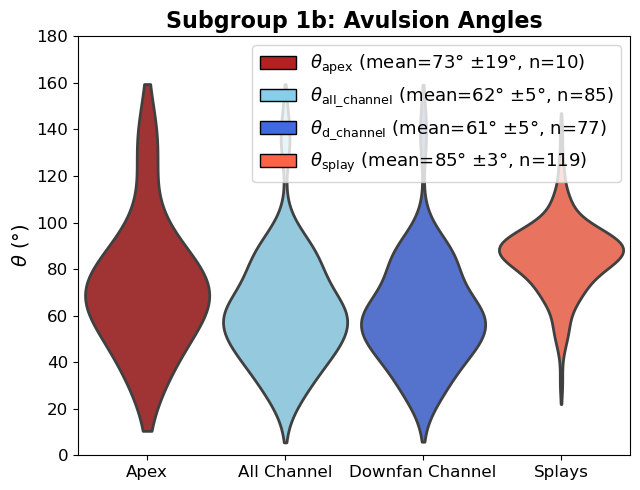

In [15]:
# 1. Group-specific settings
group_name = "Subgroup 1b"
apex_color = "#B22222" # Darker red for 1b
palette = {"Apex": apex_color, **DEFAULT_CONDITION_COLORS}

# 2. Process data using the global helper function
df_plot = prepare_combined_data(df, group_name)

# 3. Generate Violin Plot
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    data=df_plot, 
    x="Condition", 
    y="Angle", 
    hue="Condition", # Fixes palette FutureWarning
    palette=palette, 
    linewidth=2, 
    inner=None, 
    cut=1.5, 
    width=0.9,
    legend=False     # Fixes palette FutureWarning
)

# 4. Statistical legend (Mean ± 95% CI)
legend_elements = []
for cond in CONDITION_ORDER:
    data = df_plot[df_plot["Condition"] == cond]["Angle"].dropna()
    
    if not data.empty:
        n = len(data)
        mean_val = np.mean(data)
        sem = stats.sem(data)
        # T-distribution 95% CI
        ci = sem * stats.t.ppf((1 + 0.95) / 2., n - 1) if n > 1 else 0
        
        label = f"{LABEL_MAP[cond]} (mean={round(mean_val)}° ±{round(ci)}°, n={n})"
        legend_elements.append(Patch(facecolor=palette[cond], edgecolor="k", label=label))

# 5. Final layout and formatting
ax.legend(handles=legend_elements, fontsize=LEGEND_FONT, loc="upper right", frameon=True)
ax.set_title(f"{group_name}: Avulsion Angles", fontsize=TITLE_FONT, fontweight='bold')
ax.set_ylabel(r"$\theta$ (°)", fontsize=LABEL_FONT)
ax.set_xlabel("")

# FixedLocator: Set ticks before labels to avoid UserWarning
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels(["Apex", "All Channel", "Downfan Channel", "Splays"], fontsize=TICK_FONT)

ax.tick_params(axis="both", labelsize=TICK_FONT)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()

# Fig. 2e: Subgroup 2a violin plots

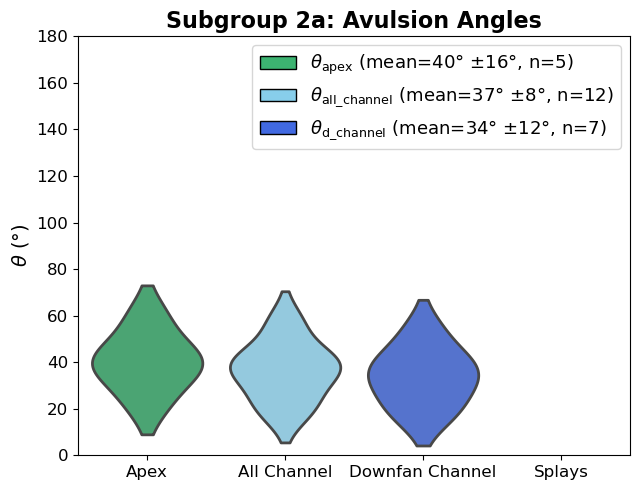

In [16]:
# 1. Group-specific settings
group_name = "Subgroup 2a"
apex_color = "mediumseagreen" 
palette = {"Apex": apex_color, **DEFAULT_CONDITION_COLORS}

# 2. Process data using the global helper function
df_plot = prepare_combined_data(df, group_name)

# 3. Generate Violin Plot
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    data=df_plot, 
    x="Condition", 
    y="Angle", 
    hue="Condition",
    palette=palette, 
    linewidth=2, 
    inner=None, 
    cut=1.5, 
    width=0.8,
    dodge=False,         # CRITICAL: This centers the violins on the ticks
    density_norm="width", # Ensures consistent thickness across categories
    legend=False     
)

# 4. Statistical legend (Only shows categories with data)
legend_elements = []
for cond in CONDITION_ORDER:
    data = df_plot[df_plot["Condition"] == cond]["Angle"].dropna()
    
    if not data.empty:
        n = len(data)
        mean_val = np.mean(data)
        sem = stats.sem(data)
        ci = sem * stats.t.ppf((1 + 0.95) / 2., n - 1) if n > 1 else 0
        
        label = f"{LABEL_MAP[cond]} (mean={round(mean_val)}° ±{round(ci)}°, n={n})"
        legend_elements.append(Patch(facecolor=palette[cond], edgecolor="k", label=label))

# 5. Final layout and formatting
ax.legend(handles=legend_elements, fontsize=LEGEND_FONT, loc="upper right", frameon=True)
ax.set_title(f"{group_name}: Avulsion Angles", fontsize=TITLE_FONT, fontweight='bold')
ax.set_ylabel(r"$\theta$ (°)", fontsize=LABEL_FONT)
ax.set_xlabel("")

# FixedLocator to maintain the "Splays" void
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels(["Apex", "All Channel", "Downfan Channel", "Splays"], fontsize=TICK_FONT)

ax.tick_params(axis="both", labelsize=TICK_FONT)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()

## Fig. 2f: Subgroup 2b violin plots

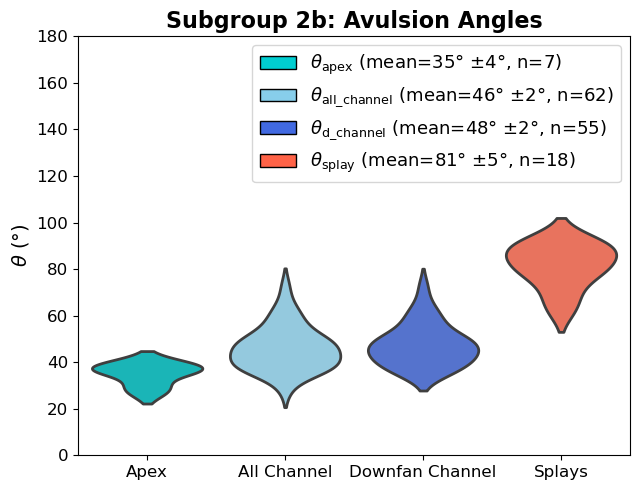

In [17]:
# 1. Group-specific settings
group_name = "Subgroup 2b"
apex_color = "#00CED1" # Dark Turquoise/Cyan for 2b
palette = {"Apex": apex_color, **DEFAULT_CONDITION_COLORS}

# 2. Process data using the global helper function
df_plot = prepare_combined_data(df, group_name)

# 3. Generate Violin Plot
plt.figure(figsize=(6.5, 5))
ax = sns.violinplot(
    data=df_plot, 
    x="Condition", 
    y="Angle", 
    hue="Condition",
    palette=palette, 
    linewidth=2, 
    inner=None, 
    cut=1.5, 
    width=0.8,
    dodge=False,         # Centering the violins on the ticks
    density_norm="width", # Consistent width across all categories
    legend=False     
)

# 4. Statistical legend (Mean ± 95% CI)
legend_elements = []
for cond in CONDITION_ORDER:
    data = df_plot[df_plot["Condition"] == cond]["Angle"].dropna()
    
    if not data.empty:
        n = len(data)
        mean_val = np.mean(data)
        sem = stats.sem(data)
        ci = sem * stats.t.ppf((1 + 0.95) / 2., n - 1) if n > 1 else 0
        
        label = f"{LABEL_MAP[cond]} (mean={round(mean_val)}° ±{round(ci)}°, n={n})"
        legend_elements.append(Patch(facecolor=palette[cond], edgecolor="k", label=label))

# 5. Final layout and formatting
ax.legend(handles=legend_elements, fontsize=LEGEND_FONT, loc="upper right", frameon=True)
ax.set_title(f"{group_name}: Avulsion Angles", fontsize=TITLE_FONT, fontweight='bold')
ax.set_ylabel(r"$\theta$ (°)", fontsize=LABEL_FONT)
ax.set_xlabel("")

# FixedLocator to avoid UserWarnings
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels(["Apex", "All Channel", "Downfan Channel", "Splays"], fontsize=TICK_FONT)

ax.tick_params(axis="both", labelsize=TICK_FONT)
ax.set_ylim(0, 180)
ax.grid(False)

plt.tight_layout()
plt.show()

## Statistics for Fig. 2

In [18]:
# Ensure fan names are consistent for grouping
df["Fan"] = df["Fan"].astype(str).str.strip()

# Defining the established subgroups
FAN_GROUPS = {
    "Subgroup 1a": ["Ili", "Abrisham", "Niger"],
    "Subgroup 1b": ["Saskatchewan", "Shire", "Okavango"],
    "Subgroup 2a": ["Canning", "Karnali", "Kosi", "Manas"],
    "Subgroup 2b": ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]
}

def assign_group(fan_name):
    for group, fans in FAN_GROUPS.items():
        if fan_name in fans:
            return group
    return np.nan

# Map the fans to their respective subgroups in the dataframe
df["Group"] = df["Fan"].apply(assign_group)


# Descriptive Statistics
subgroups = ["Subgroup 1a", "Subgroup 1b", "Subgroup 2a", "Subgroup 2b"]
group_data = {}
alpha = 0.05

print("--- SUBGROUP SUMMARY STATISTICS ---")
for g in subgroups:
    # Filter for the subgroup and extract Angle data
    vals = df.loc[df["Group"] == g, "Angle"].dropna().values
    group_data[g] = vals
    n = len(vals)

    if n > 0:
        mean_val = np.mean(vals)
        sd_val = np.std(vals, ddof=1) if n > 1 else 0
        sem_val = stats.sem(vals) if n > 1 else 0
        print(f"{g}: n={n}, mean={mean_val:.2f}°, SD={sd_val:.2f}°, SEM={sem_val:.2f}°")
    else:
        print(f"{g}: n=0, no data found")

        
        
# Normality & Variance Tests

print("\n--- ASSUMPTION TESTING ---")
valid_groups = [g for g in subgroups if len(group_data[g]) >= 3]
normality_passed = {}

for g in valid_groups:
    stat, p = stats.shapiro(group_data[g])
    is_normal = p >= alpha
    normality_passed[g] = is_normal
    print(f"{g} Normality (Shapiro-Wilk): p={p:.4f} ({'Passed' if is_normal else 'Failed'})")

    
    
# Omnibus Statistical Test

print("\n--- OMNIBUS COMPARISON ---")
all_normal = all(normality_passed.values())

if len(valid_groups) < 2:
    print("Insufficient groups for statistical comparison.")
else:
    if all_normal:
        # Check for equal variance before ANOVA
        _, p_levene = stats.levene(*[group_data[g] for g in valid_groups])
        print(f"Levene’s Test (Variance): p={p_levene:.4f}")
        
        # One-way ANOVA
        f_stat, p_omnibus = stats.f_oneway(*[group_data[g] for g in valid_groups])
        test_name = "One-way ANOVA"
    else:
        # Kruskal-Wallis (Non-parametric alternative)
        h_stat, p_omnibus = stats.kruskal(*[group_data[g] for g in valid_groups])
        test_name = "Kruskal-Wallis"

    print(f"Test Performed: {test_name}")
    print(f"Omnibus p-value: {p_omnibus:.6f}")
    print(f"Significant Difference: {'Yes' if p_omnibus < alpha else 'No'}")


    
# Pairwise Comparisons

if p_omnibus < alpha:
    print("\n--- POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U) ---")
    for g1, g2 in itertools.combinations(valid_groups, 2):
        u_stat, p_pair = stats.mannwhitneyu(group_data[g1], group_data[g2], alternative='two-sided')
        sig = "Significant" if p_pair < alpha else "Not Significant"
        print(f"{g1} vs {g2}: p={p_pair:.4f} ({sig})")

--- SUBGROUP SUMMARY STATISTICS ---
Subgroup 1a: n=372, mean=70.94°, SD=22.39°, SEM=1.16°
Subgroup 1b: n=204, mean=75.64°, SD=22.28°, SEM=1.56°
Subgroup 2a: n=12, mean=36.58°, SD=12.57°, SEM=3.63°
Subgroup 2b: n=80, mean=54.05°, SD=17.65°, SEM=1.97°

--- ASSUMPTION TESTING ---
Subgroup 1a Normality (Shapiro-Wilk): p=0.0000 (Failed)
Subgroup 1b Normality (Shapiro-Wilk): p=0.0014 (Failed)
Subgroup 2a Normality (Shapiro-Wilk): p=0.7280 (Passed)
Subgroup 2b Normality (Shapiro-Wilk): p=0.0000 (Failed)

--- OMNIBUS COMPARISON ---
Test Performed: Kruskal-Wallis
Omnibus p-value: 0.000000
Significant Difference: Yes

--- POST-HOC PAIRWISE COMPARISONS (Mann-Whitney U) ---
Subgroup 1a vs Subgroup 1b: p=0.0218 (Significant)
Subgroup 1a vs Subgroup 2a: p=0.0000 (Significant)
Subgroup 1a vs Subgroup 2b: p=0.0000 (Significant)
Subgroup 1b vs Subgroup 2a: p=0.0000 (Significant)
Subgroup 1b vs Subgroup 2b: p=0.0000 (Significant)
Subgroup 2a vs Subgroup 2b: p=0.0015 (Significant)


In [19]:
# Excluding 2a because it has n=0 for splays
groups = ["Subgroup 1a", "Subgroup 1b", "Subgroup 2b"]
splay_data = {}
alpha = 0.05

print("--- SPLAY ANGLE SUMMARY STATISTICS ---")
for g in groups:
    # Filter for specific group AND Crevasse == "Yes" (Splays)
    vals = df.loc[
        (df["Group"] == g) & (df["Crevasse"] == "Yes"), 
        "Angle"
    ].dropna().values
    
    splay_data[g] = vals
    n = len(vals)

    if n > 0:
        mean_val = np.mean(vals)
        sd_val = np.std(vals, ddof=1) if n > 1 else 0
        sem_val = stats.sem(vals) if n > 1 else 0
        print(f"{g}: n={n}, mean={mean_val:.2f}°, SD={sd_val:.2f}°, SEM={sem_val:.2f}°")
    else:
        print(f"{g}: n=0, no splay data")

        
        
# Assumption Testing (Normality)

print("\n--- NORMALITY TESTING ---")
valid_groups = [g for g in groups if len(splay_data[g]) >= 3]
normality_passed = {}

for g in valid_groups:
    stat, p = stats.shapiro(splay_data[g])
    is_normal = p >= alpha
    normality_passed[g] = is_normal
    print(f"{g} Splay Normality: p={p:.4f} ({'Passed' if is_normal else 'Failed'})")


    
# Omnibus Statistical Test

print("\n--- OMNIBUS SPLAY COMPARISON ---")
if len(valid_groups) < 2:
    print("Insufficient groups for splay angle comparison.")
else:
    all_normal = all(normality_passed.values())
    
    if all_normal:
        # One-way ANOVA
        f_stat, p_omnibus = stats.f_oneway(*[splay_data[g] for g in valid_groups])
        test_name = "One-way ANOVA"
    else:
        # Kruskal-Wallis
        h_stat, p_omnibus = stats.kruskal(*[splay_data[g] for g in valid_groups])
        test_name = "Kruskal-Wallis"

    print(f"Test Performed: {test_name}")
    print(f"Omnibus p-value: {p_omnibus:.6f}")
    print(f"Significant Difference: {'Yes' if p_omnibus < alpha else 'No'}")

    
    
# (With Bonferroni Correction)

if 'p_omnibus' in locals() and p_omnibus < alpha:
    print("\n--- PAIRWISE COMPARISONS (Bonferroni Corrected) ---")
    
    # Calculate corrected alpha
    combos = list(itertools.combinations(valid_groups, 2))
    bonf_alpha = alpha / len(combos)
    print(f"Significance Threshold (Bonferroni): {bonf_alpha:.4f}\n")

    for g1, g2 in combos:
        # Using Mann-Whitney U for robust pairwise comparison
        u_stat, p_pair = stats.mannwhitneyu(splay_data[g1], splay_data[g2], alternative='two-sided')
        sig = "Significant" if p_pair < bonf_alpha else "Not Significant"
        print(f"{g1} vs {g2}: p={p_pair:.4f} ({sig})")

--- SPLAY ANGLE SUMMARY STATISTICS ---
Subgroup 1a: n=168, mean=82.39°, SD=15.68°, SEM=1.21°
Subgroup 1b: n=119, mean=85.18°, SD=15.57°, SEM=1.43°
Subgroup 2b: n=18, mean=81.44°, SD=9.47°, SEM=2.23°

--- NORMALITY TESTING ---
Subgroup 1a Splay Normality: p=0.0000 (Failed)
Subgroup 1b Splay Normality: p=0.0018 (Failed)
Subgroup 2b Splay Normality: p=0.1904 (Passed)

--- OMNIBUS SPLAY COMPARISON ---
Test Performed: Kruskal-Wallis
Omnibus p-value: 0.281803
Significant Difference: No


# Figure 3

In [20]:
# Calculating gradients and gradient changes

def slope_deg_from_dzdx(dz_m, dx_km):
    """
    Convert rise/run to degrees.
    Inputs: elevation difference in meters (dz_m), distance in kilometers (dx_km).
    Formula: theta = arctan(dz / dx)
    """
    if dx_km <= 0 or np.isnan(dz_m):
        return np.nan
    # Convert km to m for a consistent m/m ratio
    return np.degrees(np.arctan(dz_m / (dx_km * 1000.0)))

def bulk_segment_slope_deg(dist_km, elev_m):
    """
    Calculates the bulk slope from the first point to the last point in a segment.
    Uses the absolute vertical drop to preserve the magnitude of the gradient.
    """
    if len(dist_km) < 2:
        return np.nan
    
    # dz: Vertical drop from start to end (m)
    dz = elev_m.iloc[0] - elev_m.iloc[-1]
    # dx: Horizontal distance traveled (km)
    dx = dist_km.iloc[-1] - dist_km.iloc[0]
    
    return slope_deg_from_dzdx(np.abs(dz), dx)

# Compute drainage (0 to apex) and fan (apex to end) slopes
gradient_table = []

# Assuming df2 contains your longitudinal profile data for planetary/terrestrial fans
for fan_name in df2["Fan"].unique():
    sub = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .reset_index(drop=True)
        .copy()
    )

    # Clean data: Remove exact distance duplicates to prevent division by zero
    sub = sub.loc[~sub["Distance"].duplicated()].reset_index(drop=True)

    # Identify the apex row (the transition point for geomorphology analysis)
    apex_idx_list = sub.index[sub["Apex"] == "Apex"].tolist()
    if not apex_idx_list:
        print(f"⚠️ No Apex row for fan: {fan_name}")
        continue
    apex_idx = apex_idx_list[0]

    # Segments: Drainage (catchment) vs. Fan (depositional)
    dr_segment = sub.iloc[:apex_idx + 1]
    fn_segment = sub.iloc[apex_idx:]

    # Compute slopes in degrees
    drainage_deg = bulk_segment_slope_deg(dr_segment["Distance"], dr_segment["River Elevation"])
    fan_deg      = bulk_segment_slope_deg(fn_segment["Distance"], fn_segment["River Elevation"])

    # Store results for the next phase of data visualization
    gradient_table.append({
        "Fan": fan_name,
        "Drainage Gradient (°)": np.round(drainage_deg, 6),
        "Fan Gradient (°)": np.round(fan_deg, 6),
        "Gradient Ratio (Dr/Fn)": np.round(drainage_deg / fan_deg, 6) 
            if pd.notna(drainage_deg) and pd.notna(fan_deg) and fan_deg != 0 else np.nan,
    })

gradient_df = pd.DataFrame(gradient_table)
# Display the table to verify the geomorphic characteristics
print(gradient_df)

                 Fan  Drainage Gradient (°)  Fan Gradient (°)  \
0           Abrisham               0.062521          0.031414   
1            Canning               0.178509          0.160389   
2              Cusay               3.096812          0.161223   
3                Ili               0.019473          0.010727   
4            Karnali               0.087780          0.055788   
5               Kosi               0.348264          0.017595   
6              Manas               0.255051          0.048938   
7              Niger               0.004396          0.002472   
8          Nomhon He               0.723286          0.506005   
9           Okavango               0.010337          0.009725   
10  Rud-i-Shur Tabas               0.581335          0.428419   
11      Saskatchewan               0.010743          0.006671   
12             Shire               0.020578          0.015221   

    Gradient Ratio (Dr/Fn)  
0                 1.990207  
1                 1.112975  
2 

In [21]:
# --- Subgroup Mapping ---
FAN_GROUPS = {
    "Subgroup 1a": ["Ili", "Abrisham", "Niger"],
    "Subgroup 1b": ["Saskatchewan", "Shire", "Okavango"],
    "Subgroup 2a": ["Canning", "Karnali", "Kosi", "Manas"],
    "Subgroup 2b": ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]
}

def assign_group_local(fan_name):
    """Maps fans to their specific geomorphic subgroups."""
    for group, fans in FAN_GROUPS.items():
        if fan_name in fans:
            return group
    return "Unknown"

# --- Visual Consistency (Global Colors) ---
GLOBAL_COLORS = {
    "Subgroup 1a": "#FFD700", # Yellow/Gold
    "Subgroup 1b": "#B22222", # Firebrick Red
    "Subgroup 2a": "#3CB371", # Medium Sea Green
    "Subgroup 2b": "#00CED1"  # Dark Turquoise
}

# --- Labeling Logic ---
def smart_label(ax, x, y, fan, offsets=None):
    """Applies consistent manual offsets for fan labels without connector lines."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    dx_mult = offsets.get('dx', 0.02) if offsets else 0.02
    dy_mult = offsets.get('dy', 0.01) if offsets else 0.01
    
    dx = dx_mult * (xlim[1] - xlim[0])
    dy = dy_mult * (ylim[1] - ylim[0])
    
    ax.text(x + dx, y + dy, fan, fontsize=10, ha='left', va='bottom', zorder=5)

# --- Apply Grouping Globally ---
df["Group"] = df["Fan"].apply(assign_group_local)

In [22]:
# Setting up trendlines and their display

# --- Toggle Switches ---
SHOW_TRENDLINES = True  # Set to False to omit lines
SHOW_R2_LEGEND  = True  # Set to False to omit R^2 from labels

# --- Global Settings ---
GLOBAL_COLORS = {
    "Subgroup 1a": "#FFD700", "Subgroup 1b": "#B22222",
    "Subgroup 2a": "#3CB371", "Subgroup 2b": "#00CED1"
}

def assign_group_local(fan_name):
    FAN_GROUPS = {
        "Subgroup 1a": ["Ili", "Abrisham", "Niger"],
        "Subgroup 1b": ["Saskatchewan", "Shire", "Okavango"],
        "Subgroup 2a": ["Canning", "Karnali", "Kosi", "Manas"],
        "Subgroup 2b": ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]
    }
    for group, fans in FAN_GROUPS.items():
        if fan_name in fans: return group
    return "Unknown"

def smart_label(ax, x, y, fan, offsets=None):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    dx = (offsets.get('dx', 0.02) if offsets else 0.02) * (xlim[1] - xlim[0])
    dy = (offsets.get('dy', 0.01) if offsets else 0.01) * (ylim[1] - ylim[0])
    ax.text(x + dx, y + dy, fan, fontsize=11, ha='left', va='bottom', zorder=5)

# Applying grouping to main data
df["Group"] = df["Fan"].apply(assign_group_local)

## Fig. 3a: Scatter plot of mean angle v. slope

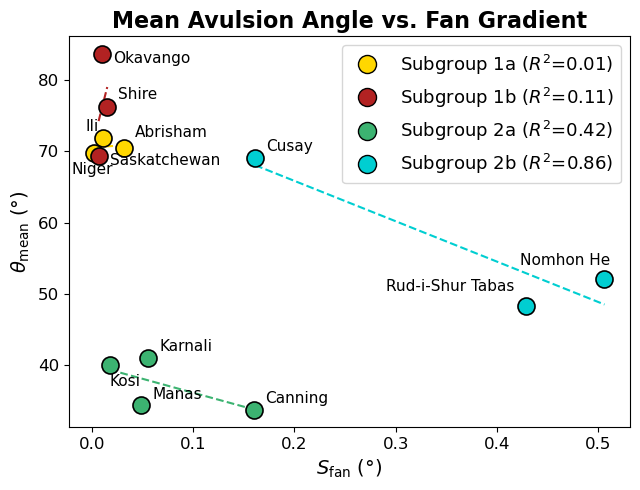

In [23]:
SHOW_TRENDLINES = True
SHOW_R2_LEGEND = True

# 1. Data Prep
plot_df = df.groupby(['Fan', 'Group'], as_index=False).agg(mean_angle=('Angle', 'mean'))
plot_df = plot_df.merge(gradient_df[['Fan', 'Fan Gradient (°)']], on='Fan', how='left')
plot_df = plot_df.rename(columns={'Fan Gradient (°)': 'mean_fan_gradient'}).dropna()

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(6.5, 5))
r2_dict = {}
manual_offsets = {
    "Abrisham": {"dx": 0.02, "dy": 0.02}, "Kosi": {"dx": 0.0, "dy": -0.06},
    "Ili": {"dx": -0.03, "dy": 0.01}, "Niger": {"dx": -0.04, "dy": -0.06},
    "Nomhon He": {"dx": -0.15, "dy": 0.03}, "Okavango": {"dx": 0.02, "dy": -0.03},
    "Rud-i-Shur Tabas": {"dx": -0.25, "dy": 0.03}, "Saskatchewan": {"dx": 0.02, "dy": -0.03},
    "Shire": {"dx": 0.02, "dy": 0.012}
}

# 3. Points and Statistics
for group, color in GROUP_COLORS.items(): # Ensure this matches your GROUP_COLORS dict name
    data = plot_df[plot_df['Group'] == group]
    if data.empty: continue
    
    # Scatter Points
    sns.scatterplot(data=data, x='mean_fan_gradient', y='mean_angle', s=150, 
                    color=color, edgecolor='black', linewidth=1.2, zorder=3, ax=ax)
    
    # Optional Trendlines
    if SHOW_TRENDLINES and len(data) >= 2:
        x, y = data['mean_fan_gradient'].values, data['mean_angle'].values
        slope, intercept, r_val, _, _ = linregress(x, y)
        r2_dict[group] = r_val ** 2
        x_range = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_range, slope * x_range + intercept, linestyle='--', color=color, zorder=2)

# 4. Labels and Legend
# Assuming smart_label is defined elsewhere in your environment
for _, row in plot_df.iterrows():
    try:
        smart_label(ax, row['mean_fan_gradient'], row['mean_angle'], row['Fan'], manual_offsets.get(row['Fan']))
    except NameError:
        ax.text(row['mean_fan_gradient'], row['mean_angle'], row['Fan'], fontsize=9)

legend_elements = []
for g in GROUP_COLORS.keys():
    if g in plot_df['Group'].unique():
        label_text = g
        if SHOW_R2_LEGEND and g in r2_dict:
            label_text += f" ($R^2$={r2_dict[g]:.2f})"
        
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=GROUP_COLORS[g],
                                     markeredgecolor='black', markersize=13, label=label_text))

ax.legend(handles=legend_elements, fontsize=13, loc='upper right', frameon=True)
ax.set_xlabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=14)
ax.set_ylabel(r"$\theta_{\mathrm{mean}}$ (°)", fontsize=14)
ax.set_title("Mean Avulsion Angle vs. Fan Gradient", fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

## Fig. 3b: Scatter plot of mean apex angle v. slope


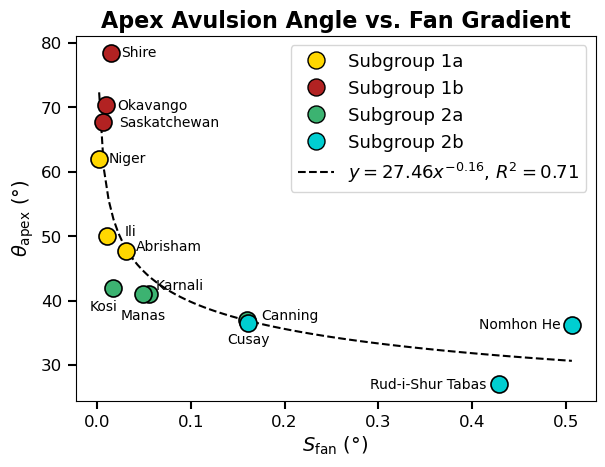

In [24]:
# --- TOGGLE GLOBAL FIT HERE ---
SHOW_GLOBAL_FIT = True 

# 1. Apex-only data preparation
df_apex = df[df["Apex"] == "Yes"].copy()
apex_summary = df_apex.groupby(["Fan", "Group"], as_index=False).agg(mean_angle=("Angle", "mean"))

plot_df_apex = apex_summary.merge(
    gradient_df[["Fan", "Fan Gradient (°)"]], on="Fan", how="left"
).rename(columns={"Fan Gradient (°)": "mean_fan_gradient"})

plot_df_apex = plot_df_apex.dropna(subset=["mean_angle", "mean_fan_gradient"])

# 2. Plot setup
fig, ax = plt.subplots(figsize=(6.5, 5))
pt_size = 150
fit_label = "" # Placeholder for legend label

# 3. Manual Nudge Definitions
manual_nudges = {
    "Rud-i-Shur Tabas": (-0.075, 0), "Nomhon He": (-0.055, 0), "Kosi": (-0.01, -3),
    "Okavango": (0.05, 0), "Shire": (0.03, 0), "Saskatchewan": (0.07, 0),
    "Niger": (0.03, 0), "Cusay": (0, -2.5), "Canning": (0.045, 0.65),
    "Ili": (0.025, 0.65), "Abrisham": (0.045, 0.65), "Manas": (0, -3.33), "Karnali": (0.033, 1.33),
}

# 4. Scatter Points (By Group)
for group, color in GLOBAL_COLORS.items():
    data = plot_df_apex[plot_df_apex["Group"] == group]
    if data.empty: continue
    ax.scatter(data["mean_fan_gradient"], data["mean_angle"],
               s=pt_size, color=color, edgecolor="black", linewidth=1.2, zorder=3)

# --- GLOBAL BEST FIT POWER LAW ---
if SHOW_GLOBAL_FIT and len(plot_df_apex) > 2:
    x_all = plot_df_apex["mean_fan_gradient"].values
    y_all = plot_df_apex["mean_angle"].values
    
    # Linear regression on log-transformed data
    slope, intercept, r_val, _, _ = linregress(np.log10(x_all), np.log10(y_all))
    
    a = 10**intercept
    b = slope
    r_squared = r_val**2
    
    # Create line for plotting
    x_range = np.linspace(x_all.min(), x_all.max(), 100)
    y_fit = a * (x_range**b)
    
    ax.plot(x_range, y_fit, color='black', linestyle='--', linewidth=1.5, zorder=2)
    
    # Equation string for the legend label
    fit_label = f"$y = {a:.2f}x^{{{b:.2f}}}$, $R^2 = {r_squared:.2f}$"

# 5. Labels (Manual + Auto)
texts = []
for _, row in plot_df_apex.iterrows():
    fan_name = row["Fan"]
    x, y = row["mean_fan_gradient"], row["mean_angle"]
    if fan_name in manual_nudges:
        dx, dy = manual_nudges[fan_name]
        ax.text(x + dx, y + dy, fan_name, fontsize=10, fontweight='medium', va='center', ha='center', zorder=5)
    else:
        texts.append(ax.text(x, y, fan_name, fontsize=10, fontweight='medium'))

if texts:
    adjust_text(texts, ax=ax, expand_points=(1.2, 1.2), force_points=0.1,
                arrowprops=dict(arrowstyle='-', color='gray', alpha=0.3))

# 6. Formatting
ax.set_xlabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=14)
ax.set_ylabel(r"$\theta_{\mathrm{apex}}$ (°)", fontsize=14)
ax.set_title("Apex Avulsion Angle vs. Fan Gradient", fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.5)

# 7. Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=GLOBAL_COLORS[g], 
           markeredgecolor='black', markersize=np.sqrt(pt_size), label=g)
    for g in GLOBAL_COLORS.keys() if g in plot_df_apex["Group"].unique()
]

# Add the black dashed line using the equation string as the label
if SHOW_GLOBAL_FIT and fit_label:
    legend_elements.append(Line2D([0], [0], color='black', linestyle='--', label=fit_label))

ax.legend(handles=legend_elements, fontsize=13, loc='upper right', frameon=True)

plt.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.15)
plt.show()

## Fig. 3c: Mean apex angle v. apex gradient change

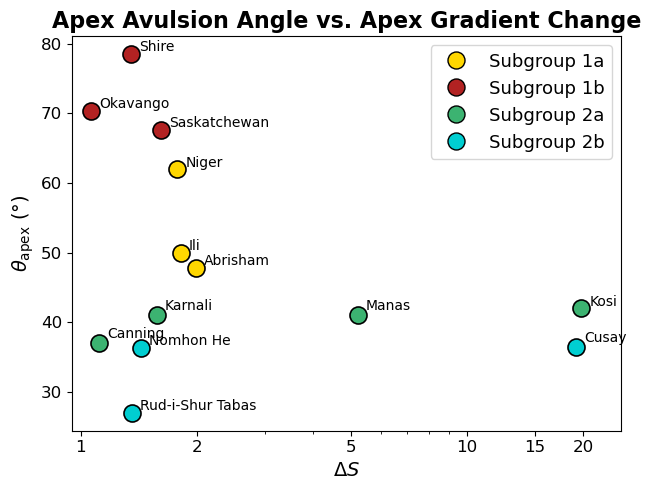

In [25]:
# 1. Assign groups
df["Group"] = df["Fan"].apply(assign_group)

# 2. Apex-only mean per fan
df_apex = df[df["Apex"] == "Yes"].copy()
apex_summary = (
    df_apex.groupby(["Fan", "Group"], as_index=False)
           .agg(mean_apex_angle=("Angle", "mean"))
)

# 3. Merge ΔS
plot_df = (
    gradient_df[["Fan", "Gradient Ratio (Dr/Fn)"]]
    .merge(apex_summary, on="Fan", how="left")
    .rename(columns={"Gradient Ratio (Dr/Fn)": "ΔS"})
)

# 4. Clean Data
plot_df = plot_df.dropna(subset=["ΔS", "mean_apex_angle", "Group"])

if plot_df.empty:
    print("⚠️ ERROR: plot_df is empty.")
else:
    # 5. Figure Generation
    fig, ax = plt.subplots(figsize=(6.5, 5))
    pt_size = 150 

    for g, color in GLOBAL_COLORS.items():
        data = plot_df[plot_df["Group"] == g]
        if data.empty:
            continue

        ax.scatter(
            data["ΔS"],
            data["mean_apex_angle"],
            s=pt_size,
            color=color,
            edgecolor="black",
            linewidth=1.2,
            zorder=3
        )

    # 6. Log axis + custom ticks
    ax.set_xscale("log")
    ax.set_xlim(.95, 25) 

    ax.set_xticks([1, 2, 5, 10, 15, 20])
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())

    # 7. Labels
    for _, row in plot_df.iterrows():
        x_pos = row["ΔS"] * 1.05 
        y_pos = row["mean_apex_angle"] + 0.3

        if 'manual_offsets' in locals() and row["Fan"] in manual_offsets:
            mo = manual_offsets[row["Fan"]]
            x_pos = row["ΔS"] * mo.get("dx_mult", 1.05)
            y_pos = row["mean_apex_angle"] + mo.get("dy", 0.3)

        ax.text(
            x_pos, 
            y_pos, 
            row["Fan"], 
            fontsize=10,
            va='bottom',
            ha='left'
        )

    # 8. Legend (Marker size matched to sqrt of scatter size)
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=GLOBAL_COLORS[g],
               markeredgecolor='black', markersize=np.sqrt(pt_size), label=g)
        for g in GLOBAL_COLORS.keys() if g in plot_df["Group"].unique()
    ]
    ax.legend(handles=legend_elements, fontsize=13, loc="upper right", frameon=True)

    # 9. Formatting
    ax.set_xlabel(r"$\Delta S$", fontsize=14)
    ax.set_ylabel(r"$\theta_{\mathrm{apex}}$ (°)", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title("Apex Avulsion Angle vs. Apex Gradient Change", fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

## Fig. 3d: Drainage slope v. fan slope

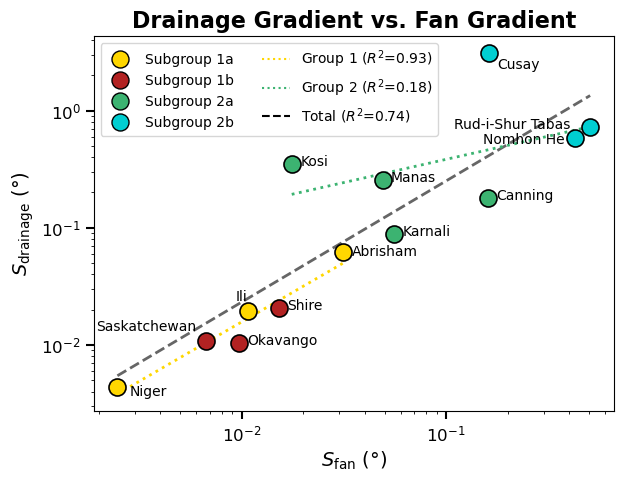

In [27]:
# --- TOGGLE R^2 DISPLAY ---
SHOW_R2 = True 
# --------------------------

# 1. Define the Major Group Mapping
GROUP_MAPPING = {
    "Subgroup 1a": "Group 1", "Subgroup 1b": "Group 1",
    "Subgroup 2a": "Group 2", "Subgroup 2b": "Group 2"
}

# Ensure Group assignment is present and create the Major Group column
if "Group" not in gradient_df.columns:
    gradient_df = gradient_df.merge(
        df[["Fan", "Group"]].drop_duplicates(), on="Fan", how="left"
    )
gradient_df["Major_Group"] = gradient_df["Group"].map(GROUP_MAPPING)

# 2. Figure Setup
fig, ax = plt.subplots(figsize=(6.5, 5))
pt_size = 150 
r2_dict = {}

# 3. Scatter Points (Keep Subgroup colors)
for subgroup, color in GLOBAL_COLORS.items():
    subset = gradient_df[gradient_df["Group"] == subgroup].dropna(subset=["Fan Gradient (°)", "Drainage Gradient (°)"])
    if subset.empty: continue
    ax.scatter(subset["Fan Gradient (°)"], subset["Drainage Gradient (°)"], 
               s=pt_size, color=color, edgecolor="black", linewidth=1.2, zorder=4)

# 4. Group Trendlines (DOTTED Lines for Group 1 & Group 2)
# Group 1 uses Subgroup 1a's color, Group 2 uses Subgroup 2a's color for the lines
line_colors = {"Group 1": GLOBAL_COLORS["Subgroup 1a"], "Group 2": GLOBAL_COLORS["Subgroup 2a"]}

for mg in ["Group 1", "Group 2"]:
    subset = gradient_df[gradient_df["Major_Group"] == mg].dropna(subset=["Fan Gradient (°)", "Drainage Gradient (°)"])
    if len(subset) >= 2:
        x, y = subset["Fan Gradient (°)"].values, subset["Drainage Gradient (°)"].values
        slope, intercept, r, _, _ = linregress(np.log10(x), np.log10(y))
        r2_dict[mg] = r**2
        
        x_line = np.geomspace(x.min(), x.max(), 100)
        y_line = (10**intercept) * (x_line ** slope)
        ax.plot(x_line, y_line, linestyle=":", linewidth=2, color=line_colors[mg], zorder=2)

# 5. Total Trendline (DASHED Line for All Fans)
all_data = gradient_df.dropna(subset=["Fan Gradient (°)", "Drainage Gradient (°)"])
if len(all_data) >= 2:
    x_all, y_all = all_data["Fan Gradient (°)"].values, all_data["Drainage Gradient (°)"].values
    slope, intercept, r, _, _ = linregress(np.log10(x_all), np.log10(y_all))
    r2_dict["Total"] = r**2
    
    x_line = np.geomspace(x_all.min(), x_all.max(), 100)
    y_line = (10**intercept) * (x_line ** slope)
    ax.plot(x_line, y_line, linestyle="--", linewidth=2, color="black", zorder=1, alpha=0.6)

# 6. Manual Labels
manual_tweaks = {
    "Abrisham": (1.1, 1.0), "Cusay": (1.1, 0.8), "Nomhon He": (0.75, 0.775),
    "Rud-i-Shur Tabas": (0.95, 1.3), "Niger": (1.15, 0.9), "Ili": (1, 1.33),
    "Saskatchewan": (0.9, 1.33),
}

for _, row in gradient_df.iterrows():
    fan = row["Fan"]
    xf, yf = row["Fan Gradient (°)"], row["Drainage Gradient (°)"]
    if pd.isna(xf) or pd.isna(yf): continue
    mx, my = manual_tweaks.get(fan, (1.1, 1.05))
    ax.text(xf * mx, yf * my, fan, fontsize=10, zorder=5, 
            va='center', ha='left' if mx > 1 else 'right')

# 7. Axes & Log Scaling
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=14)
ax.set_ylabel(r"$S_{\mathrm{drainage}}$ (°)", fontsize=14)
ax.set_title("Drainage Gradient vs. Fan Gradient", fontsize=16, fontweight='bold')
ax.tick_params(axis="both", which='major', labelsize=12, length=6, width=1.5)

# 8. Legend
handles = []
# Markers
for g in GLOBAL_COLORS.keys():
    if g in gradient_df["Group"].unique():
        handles.append(mlines.Line2D([], [], color=GLOBAL_COLORS[g], marker='o', linestyle='None',
                          markersize=np.sqrt(pt_size), markeredgecolor='black', label=g))

# Line Definitions in Legend
if SHOW_R2:
    handles.append(mlines.Line2D([], [], color=line_colors["Group 1"], linestyle=":", 
                                 label=f"Group 1 ($R^2$={r2_dict.get('Group 1', 0):.2f})"))
    handles.append(mlines.Line2D([], [], color=line_colors["Group 2"], linestyle=":", 
                                 label=f"Group 2 ($R^2$={r2_dict.get('Group 2', 0):.2f})"))
    handles.append(mlines.Line2D([], [], color='black', linestyle="--", 
                                 label=f"Total ($R^2$={r2_dict.get('Total', 0):.2f})"))

ax.legend(handles=handles, fontsize=10, loc="upper left", frameon=True, ncol=2)

plt.subplots_adjust(left=0.15, right=0.95, top=0.90, bottom=0.15)
plt.show()

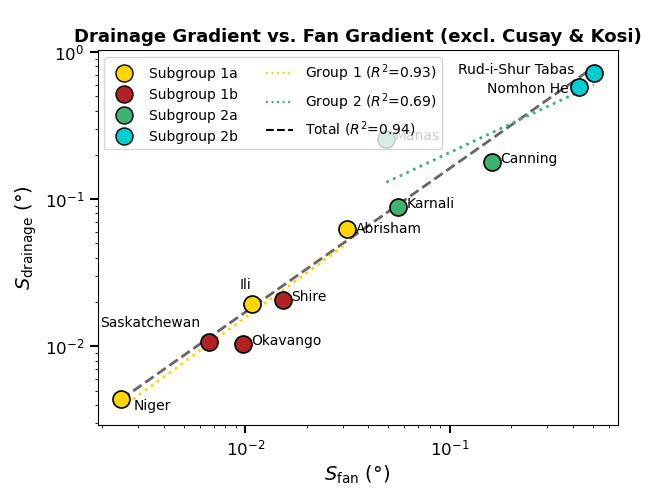

In [40]:
# --- TOGGLE OPTIONS ---
SHOW_R2 = True 
INCLUDE_KOSI_CUSAY = False   # Include/exclude Kosi and Cusay fans
# ----------------------

# 1. Define the Major Group Mapping
GROUP_MAPPING = {
    "Subgroup 1a": "Group 1", "Subgroup 1b": "Group 1",
    "Subgroup 2a": "Group 2", "Subgroup 2b": "Group 2"
}

# Ensure Group assignment is present and create the Major Group column
if "Group" not in gradient_df.columns:
    gradient_df = gradient_df.merge(
        df[["Fan", "Group"]].drop_duplicates(), on="Fan", how="left"
    )

gradient_df["Major_Group"] = gradient_df["Group"].map(GROUP_MAPPING)

# 1b. Optional Kosi/Cusay filtering
if INCLUDE_KOSI_CUSAY:
    plot_df = gradient_df.copy()
else:
    plot_df = gradient_df[~gradient_df["Fan"].isin(["Kosi", "Cusay"])].copy()


# 2. Figure Setup
fig, ax = plt.subplots(figsize=(6.5, 5))
pt_size = 150 
r2_dict = {}


# 3. Scatter Points (Keep Subgroup colors)
for subgroup, color in GLOBAL_COLORS.items():
    subset = plot_df[
        plot_df["Group"] == subgroup
    ].dropna(subset=["Fan Gradient (°)", "Drainage Gradient (°)"])

    if subset.empty:
        continue

    ax.scatter(
        subset["Fan Gradient (°)"], 
        subset["Drainage Gradient (°)"], 
        s=pt_size, 
        color=color, 
        edgecolor="black", 
        linewidth=1.2, 
        zorder=4
    )


# 4. Group Trendlines (DOTTED Lines for Group 1 & Group 2)
# Group 1 uses Subgroup 1a's color, Group 2 uses Subgroup 2a's color
line_colors = {
    "Group 1": GLOBAL_COLORS["Subgroup 1a"], 
    "Group 2": GLOBAL_COLORS["Subgroup 2a"]
}

for mg in ["Group 1", "Group 2"]:

    subset = plot_df[
        plot_df["Major_Group"] == mg
    ].dropna(subset=["Fan Gradient (°)", "Drainage Gradient (°)"])

    if len(subset) >= 2:

        x = subset["Fan Gradient (°)"].values
        y = subset["Drainage Gradient (°)"].values

        slope, intercept, r, _, _ = linregress(
            np.log10(x), 
            np.log10(y)
        )

        r2_dict[mg] = r**2

        x_line = np.geomspace(x.min(), x.max(), 100)
        y_line = (10**intercept) * (x_line ** slope)

        ax.plot(
            x_line, 
            y_line,
            linestyle=":",
            linewidth=2,
            color=line_colors[mg],
            zorder=2
        )


# 5. Total Trendline (DASHED Line for All Fans)
all_data = plot_df.dropna(
    subset=["Fan Gradient (°)", "Drainage Gradient (°)"]
)

if len(all_data) >= 2:

    x_all = all_data["Fan Gradient (°)"].values
    y_all = all_data["Drainage Gradient (°)"].values

    slope, intercept, r, _, _ = linregress(
        np.log10(x_all),
        np.log10(y_all)
    )

    r2_dict["Total"] = r**2

    x_line = np.geomspace(x_all.min(), x_all.max(), 100)
    y_line = (10**intercept) * (x_line ** slope)

    ax.plot(
        x_line,
        y_line,
        linestyle="--",
        linewidth=2,
        color="black",
        zorder=1,
        alpha=0.6
    )


# 6. Manual Labels
manual_tweaks = {
    "Abrisham": (1.1, 1.0),
    "Cusay": (1.1, 0.8),
    "Nomhon He": (0.75, 0.775),
    "Rud-i-Shur Tabas": (0.95, 1.3),
    "Niger": (1.15, 0.9),
    "Ili": (1, 1.33),
    "Saskatchewan": (0.9, 1.33),
}

for _, row in plot_df.iterrows():

    fan = row["Fan"]
    xf = row["Fan Gradient (°)"]
    yf = row["Drainage Gradient (°)"]

    if pd.isna(xf) or pd.isna(yf):
        continue

    mx, my = manual_tweaks.get(
        fan, 
        (1.1, 1.05)
    )

    ax.text(
        xf * mx,
        yf * my,
        fan,
        fontsize=10,
        zorder=5,
        va="center",
        ha="left" if mx > 1 else "right"
    )


# 7. Axes & Log Scaling
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"$S_{\mathrm{fan}}$ (°)", 
    fontsize=14
)

ax.set_ylabel(
    r"$S_{\mathrm{drainage}}$ (°)", 
    fontsize=14
)

ax.set_title(
    "Drainage Gradient vs. Fan Gradient (excl. Cusay & Kosi)",
    fontsize=13,
    fontweight="bold"
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    length=6,
    width=1.5
)


# 8. Legend
handles = []

# Markers
for g in GLOBAL_COLORS.keys():

    if g in plot_df["Group"].unique():

        handles.append(
            mlines.Line2D(
                [],
                [],
                color=GLOBAL_COLORS[g],
                marker="o",
                linestyle="None",
                markersize=np.sqrt(pt_size),
                markeredgecolor="black",
                label=g
            )
        )


# Trendline definitions
if SHOW_R2:

    handles.append(
        mlines.Line2D(
            [],
            [],
            color=line_colors["Group 1"],
            linestyle=":",
            label=f"Group 1 ($R^2$={r2_dict.get('Group 1',0):.2f})"
        )
    )

    handles.append(
        mlines.Line2D(
            [],
            [],
            color=line_colors["Group 2"],
            linestyle=":",
            label=f"Group 2 ($R^2$={r2_dict.get('Group 2',0):.2f})"
        )
    )

    handles.append(
        mlines.Line2D(
            [],
            [],
            color="black",
            linestyle="--",
            label=f"Total ($R^2$={r2_dict.get('Total',0):.2f})"
        )
    )


ax.legend(
    handles=handles,
    fontsize=10,
    loc="upper left",
    frameon=True,
    ncol=2
)


plt.subplots_adjust(
    left=0.15,
    right=0.95,
    top=0.90,
    bottom=0.15
)

plt.show()

## Fig. 3e: Fan topographic profiles

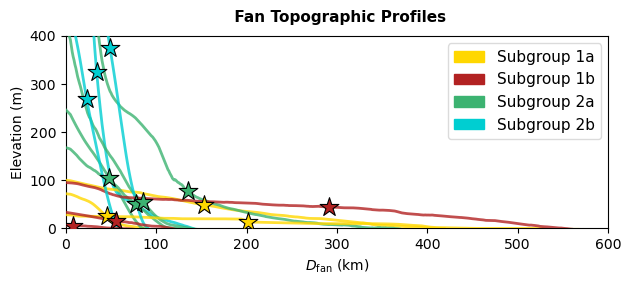

In [28]:
# 1. Figure Setup
# Define the missing reference to fix the NameError
colors = GROUP_COLORS 

fig, ax = plt.subplots(figsize=(7, 2.5))
window_size = 10 

# 2. Plotting Loop
for fan in df2["Fan"].unique():
    df_fan = df2[df2["Fan"] == fan].copy().sort_values("Distance").reset_index(drop=True)
    
    # Smooth elevations
    df_fan["Confinement_smooth"] = df_fan["Mean Elevation"].rolling(
        window=window_size, min_periods=1, center=True
    ).mean()
    df_fan["River_smooth"] = df_fan["River Elevation"].rolling(
        window=window_size, min_periods=1, center=True
    ).mean()
    
    # Normalize to local base level
    min_elev = df_fan["Confinement_smooth"].min()
    df_fan["River_norm"] = df_fan["River_smooth"] - min_elev
    
    # Retrieve group and color from global definitions
    group = assign_group(fan) 
    color = colors.get(group, "gray")
    
    # Plot profiles
    ax.plot(
        df_fan["Distance"],
        df_fan["River_norm"],
        color=color,
        linewidth=2,
        alpha=0.8,
        zorder=3
    )
    
    # Apex markers (stars)
    apex_idx = df_fan[df_fan["Apex"].isin(["Apex", "Both"])].index
    if len(apex_idx) > 0:
        ax.scatter(
            df_fan.loc[apex_idx, "Distance"],
            df_fan.loc[apex_idx, "River_norm"],
            facecolor=color,
            edgecolor="black",
            marker="*",
            s=200, 
            linewidth=0.8,
            zorder=5
        )

# 3. Formatting
ax.set_ylabel("Elevation (m)", fontsize=10)
ax.set_xlabel(r"$D_{\mathrm{fan}}$ (km)", fontsize=10)
ax.set_xlim(left=0)
ax.set_ylim(0, 400)
ax.set_title(" Fan Topographic Profiles", fontsize=11, fontweight='bold', pad=10)
ax.grid(False)

# 4. Publication-Ready Legend
handles = [
    mpatches.Patch(color=colors[sub], label=sub)
    for sub in ["Subgroup 1a", "Subgroup 1b", "Subgroup 2a", "Subgroup 2b"]
    if sub in colors
]

ax.legend(
    handles=handles, 
    fontsize=11, 
    loc="upper right", 
    frameon=True, 
    fancybox=True,
    framealpha=0.8,
    edgecolor="lightgrey"
)

plt.show()

# Figure S5

## Fig. S5a: Drainage v. Fan channel widths

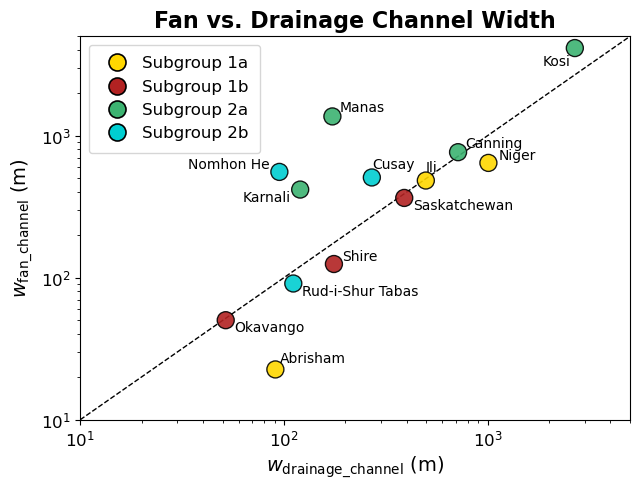

In [29]:
# ---------------------------------------------------------
# 1. Define Groups & Colors
# ---------------------------------------------------------
subgroup_1a_fans = ["Abrisham", "Ili", "Niger"]
subgroup_1b_fans = ["Okavango", "Saskatchewan", "Shire"]
subgroup_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
subgroup_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

colors = {
    "Subgroup 1a": "#FFD700",   # Gold
    "Subgroup 1b": "#B22222",   # Deep Red
    "Subgroup 2a": "#3CB371",   # Green
    "Subgroup 2b": "#00CED1"    # Cyan
}

def assign_group(fan):
    if fan in subgroup_1a_fans: return "Subgroup 1a"
    if fan in subgroup_1b_fans: return "Subgroup 1b"
    if fan in subgroup_2a_fans: return "Subgroup 2a"
    if fan in subgroup_2b_fans: return "Subgroup 2b"
    return "Unknown"

df3["Group"] = df3["Fan"].apply(assign_group)

# ---------------------------------------------------------
# 2. Compute Mean Widths
# ---------------------------------------------------------
drainage_cols = ["Drainage10", "Drainage8", "Drainage6", "Drainage4", "Drainage2"]
fan_cols = ["Fan2", "Fan4", "Fan6", "Fan8", "Fan10"]

df3["Mean_Drainage_Width"] = df3[drainage_cols].mean(axis=1, skipna=True)
df3["Mean_Fan_Width"] = df3[fan_cols].mean(axis=1, skipna=True)

# ---------------------------------------------------------
# 3. MANUAL OFFSETS (Tweak these multipliers to move labels)
# ---------------------------------------------------------
# dx > 1.0 moves Right, dx < 1.0 moves Left
# dy > 1.0 moves Up, dy < 1.0 moves Down
manual_offsets = {
    "Ili": {"dx": 1.00, "dy": 1.1},
    "Okavango": {"dx": 1.1, "dy": .98},
    "Cusay": {"dx": 1.0, "dy": 1.09},
    "Niger": {"dx": 1.12, "dy": 1.0},
    "Kosi": {"dx": .95, "dy": .9},
    "Abrisham": {"dx": 1.05, "dy": 1.05},
    "Saskatchewan": {"dx": 1.10, "dy": .98},
    "Nomhon He": {"dx": .9, "dy": 1.0},
    "Karnali": {"dx": .9, "dy": .98},
    "Rud-i-Shur Tabas": {"dx": 1.1, "dy": .98},
    "Shire": {"dx": 1.1, "dy": 1.0},

}

# ---------------------------------------------------------
# 4. Create Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))

# 1:1 reference line (Matched to plot limits to avoid scrunching)
ax.plot([10, 5000], [10, 5000], "k--", lw=1, zorder=1)

# Scatter points
sns.scatterplot(
    data=df3,
    x="Mean_Drainage_Width",
    y="Mean_Fan_Width",
    hue="Group",
    palette=colors,
    s=150,
    edgecolor="black",
    alpha=0.9,
    legend=False,
    zorder=2,
    ax=ax
)

# ---------------------------------------------------------
# 5. Manual Labels Loop
# ---------------------------------------------------------
for _, row in df3.iterrows():
    name = row["Fan"]
    
    # Get custom offset or use a very small default nudge
    off = manual_offsets.get(name, {"dx": 1.08, "dy": 1.02})
    dx = off.get("dx", 1.08)
    dy = off.get("dy", 1.02)
    
    ax.text(
        row["Mean_Drainage_Width"] * dx, 
        row["Mean_Fan_Width"] * dy, 
        name, 
        fontsize=10, 
        # Auto-align: if we moved it to the left (dx < 1), align text right
        ha="left" if dx >= 1.0 else "right",
        va="bottom" if dy >= 1.0 else "top",
        zorder=5
    )

# ---------------------------------------------------------
# 6. Formatting & Axes
# ---------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

# STRICT limits to keep the "view" exactly where the data is
ax.set_xlim(10, 5000)
ax.set_ylim(10, 5000)
ax.set_title("Fan vs. Drainage Channel Width", fontsize=16, fontweight='bold')
ax.set_xlabel(r"$w_{\mathrm{drainage\_channel}}$ (m)", fontsize=14)
ax.set_ylabel(r"$w_{\mathrm{fan\_channel}}$ (m)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(False)

# ---------------------------------------------------------
# 7. Legend (Matched to your other projects)
# ---------------------------------------------------------
msize = np.sqrt(150)
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='white', markerfacecolor=colors[g],
                  linestyle='None', markersize=msize, 
                  markeredgecolor='black', markeredgewidth=1.2, label=g)
    for g in ["Subgroup 1a", "Subgroup 1b", "Subgroup 2a", "Subgroup 2b"]
]

ax.legend(
    handles=legend_elements, 
    fontsize=12, 
    loc="upper left", 
    frameon=True,
    handletextpad=0.5,
    borderpad=0.7
)

plt.tight_layout()
plt.show()

In [30]:
# 1. Calculate the Fan / Drainage Channel Width Ratio for each row
df3["Width_Ratio"] = df3["Mean_Fan_Width"] / df3["Mean_Drainage_Width"]

print("--- Width Ratio Ranges (Mean Fan Width / Mean Drainage Width) ---")

# 2. Group by the new 'Group' column and calculate min and max
ratio_ranges = df3.groupby("Group")["Width_Ratio"].agg(["min", "max"])

# 3. Display the results nicely
for group, row in ratio_ranges.iterrows():
    print(f"{group}: {row['min']:.2f} to {row['max']:.2f}")

--- Width Ratio Ranges (Mean Fan Width / Mean Drainage Width) ---
Subgroup 1a: 0.25 to 0.97
Subgroup 1b: 0.71 to 0.97
Subgroup 2a: 1.07 to 7.89
Subgroup 2b: 0.82 to 5.85


## Supplemental Fig. S5b: Fan gradient vs. fan radius

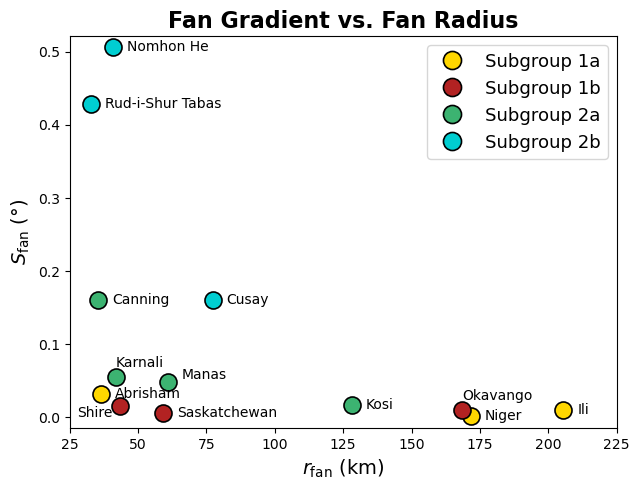

In [31]:
# --- 1. CONFIGURATION & COLORS ---
colors = GROUP_COLORS  
TITLE_FONT = 16

# --- 2. MANUAL LABEL ADJUSTMENTS ---
manual_offsets = {
    "Abrisham":        {"px": 10, "py": 0},
    "Canning":         {"px": 10, "py": 0},
    "Cusay":           {"px": 10, "py": 0},
    "Ili":             {"px": 10, "py": 0},
    "Karnali":         {"px": 0, "py": 10},
    "Kosi":            {"px": 10, "py": 0},
    "Manas":           {"px": 10, "py": 5},
    "Niger":           {"px": 10, "py": 0},
    "Nomhon He":       {"px": 10, "py": 0},
    "Okavango":        {"px": 0, "py": 10},
    "Rud-i-Shur Tabas":{"px": 10, "py": 0},
    "Saskatchewan":    {"px": 10, "py": 0},
    "Shire":           {"px": -5, "py": -5}
}

# --- 3. Compute Haversine Fan Radius ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = (np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

radius_data = [{"Fan": fan, "r_fan_haversine": haversine(c["apex"][0], c["apex"][1], c["toe"][0], c["toe"][1])} 
               for fan, c in site_coords.items()]
radius_df = pd.DataFrame(radius_data)

# --- 4. Data Prep ---
plot_df = pd.merge(gradient_df, radius_df, on="Fan")
plot_df["Group"] = plot_df["Fan"].apply(assign_group)
plot_df["S_fan (°)"] = plot_df["Fan Gradient (°)"]

# --- 5. Plotting ---
fig, ax = plt.subplots(figsize=(6.5, 5))

for group, color in colors.items():
    subset = plot_df[plot_df["Group"] == group].dropna(subset=["r_fan_haversine", "S_fan (°)"])
    if subset.empty: continue
    ax.scatter(subset["r_fan_haversine"], subset["S_fan (°)"], 
               s=150, color=color, edgecolor="black", linewidth=1.2, zorder=3)

# --- 6. Apply Manual Label Nudges ---
for _, row in plot_df.iterrows():
    fan_name = row["Fan"]
    x_val, y_val = row["r_fan_haversine"], row["S_fan (°)"]
    if pd.isna(x_val) or pd.isna(y_val): continue

    off = manual_offsets.get(fan_name, {"px": 9, "py": 0})
    px, py = off["px"], off["py"]
    h_align = 'left' if px >= 0 else 'right'
    
    ax.text(
        x_val, y_val, fan_name,
        fontsize=10, ha=h_align, va='center',
        transform=transforms.offset_copy(ax.transData, fig=fig, x=px, y=py, units='points'),
        zorder=5
    )

# --- 7. Formatting ---
ax.set_xlim(25, 225) 
ax.set_ylim(bottom=-0.015, top=plot_df["S_fan (°)"].max() * 1.03)
ax.set_xlabel(r"$r_{\mathrm{fan}}$ (km)", fontsize=14)
ax.set_ylabel(r"$S_{\mathrm{fan}}$ (°)", fontsize=14)
ax.set_title("Fan Gradient vs. Fan Radius", fontsize=TITLE_FONT, fontweight='bold')

# Legend with markersize set to 13 to match your other plots
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='white', markerfacecolor=colors[g],
                  markeredgecolor='black', markeredgewidth=1.2, markersize=13,
                  linestyle='None', label=g) 
    for g in colors.keys() if g in plot_df["Group"].unique()
]
ax.legend(handles=legend_elements, fontsize=13, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

## Supplemental Fig. S5c: Apex avulsion angle v. Confinement loss

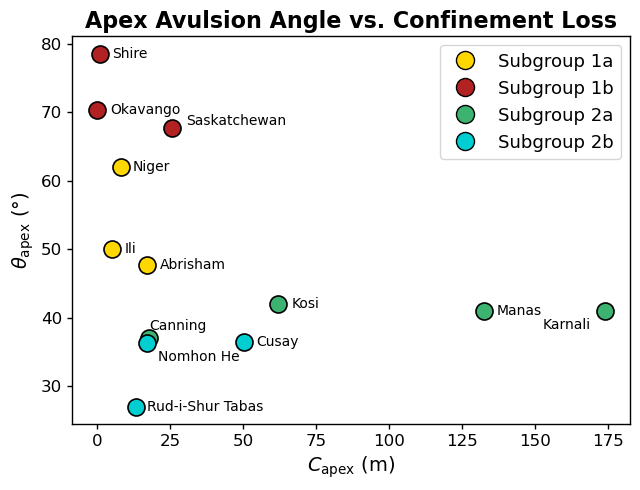

In [32]:
# --- 0. Setup Manual Offsets & Colors ---
colors = GROUP_COLORS  
manual_offsets_3c = {
    "Nomhon He": {"px": 8, "py": -10}, 
    "Rud-i-Shur Tabas": {"px": 8, "py": 0},
    "Kosi": {"px": 10, "py": 0}, 
    "Saskatchewan": {"px": 10, "py": 5},
    "Canning": {"px": 0, "py": 9},
    "Karnali": {"px": -10, "py": -10}
}

# --- 1. Calculate Mean Apex Angle ---
apex_angle = (
    df[df["Apex"].astype(str).str.lower().isin(["yes", "apex"])]
    .groupby(["Fan"], as_index=False)
    .agg(mean_apex_angle=("Angle", "mean"))
)

# --- 2. Calculate Confinement Summary ---
conf_table = []
for fan_name in df2["Fan"].unique():
    sub = df2[df2["Fan"] == fan_name].sort_values("Distance").reset_index(drop=True)
    apex_mask = sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])
    apex_idx_list = sub.index[apex_mask].tolist()
    
    if not apex_idx_list:
        continue
    
    apex_dist = sub.loc[apex_idx_list[0], "Distance"]
    pre_apex = sub[(sub["Distance"] < apex_dist) & (sub["Distance"] >= (apex_dist - 3))].copy()

    if not pre_apex.empty:
        conf_loss = pre_apex["Mean Elevation"].mean() - pre_apex["River Elevation"].mean() 
        conf_table.append({"Fan": fan_name, "C_apex_3km": conf_loss})

conf_summary_df = pd.DataFrame(conf_table)

# --- 3. Merging ---
x_col = "C_apex_3km"
plot_df = apex_angle.merge(conf_summary_df, on="Fan", how="left")
plot_df["Group"] = plot_df["Fan"].apply(assign_group)
plot_df = plot_df.dropna(subset=["Group", x_col, "mean_apex_angle"])

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(6.5, 5))

for g, col in colors.items():
    sub = plot_df[plot_df["Group"] == g]
    if sub.empty: continue
    ax.scatter(sub[x_col], sub["mean_apex_angle"], 
               s=150, color=col, edgecolor="black", linewidth=1.2, zorder=3)

# --- 5. Labels ---
for _, r in plot_df.iterrows():
    fan_name = r["Fan"]
    x_val, y_val = r[x_col], r["mean_apex_angle"]
    off = manual_offsets_3c.get(fan_name, {"px": 9, "py": 0})
    px, py = off["px"], off["py"]
    h_align = 'left' if px >= 0 else 'right'
    
    ax.text(x_val, y_val, fan_name, fontsize=10, ha=h_align, va='center',
            transform=transforms.offset_copy(ax.transData, fig=fig, x=px, y=py, units='points'),
            zorder=5)

# --- 6. STANDARD FORMATTING ---
ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=14)
ax.set_ylabel(r"$\theta_{\mathrm{apex}}$ (°)", fontsize=14)
ax.set_title("Apex Avulsion Angle vs. Confinement Loss", fontsize=16, fontweight='bold')

# Resetting the border to a standard, non-bolded weight
for spine in ax.spines.values():
    spine.set_linewidth(1.0)  # Standard weight

# Standard ticks
ax.tick_params(axis="both", labelsize=12, width=1.0)
ax.grid(False)

# Consistent Legend
handles = [
    mlines.Line2D([], [], marker='o', linestyle='None', markerfacecolor=colors[g],
                  markeredgecolor='black', markersize=13, label=g)
    for g in colors.keys() if g in plot_df["Group"].unique()
]
ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=13)

plt.tight_layout()
plt.show()

## Fig. S5d: Gradient change v. Confinement loss

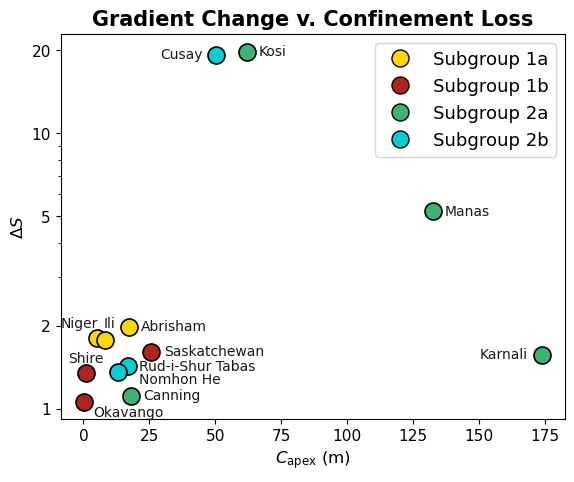

In [33]:
# --- 0a. Define the Grouping Function ---
def assign_all_subgroups(f):
    if f in ["Abrisham", "Ili", "Niger"]: return "Subgroup 1a"
    if f in ["Okavango", "Saskatchewan", "Shire"]: return "Subgroup 1b"
    if f in ["Canning", "Karnali", "Kosi", "Manas"]: return "Subgroup 2a"
    if f in ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]: return "Subgroup 2b"
    return np.nan

# Setup Manual Offsets (Point-based) ---
manual_offsets_3d = {
    "Cusay": {"px": -10, "py": 0},
    "Karnali": {"px": -10, "py": 0},
    "Nomhon He": {"px": 8, "py": -10},
    "Ili": {"px": 5, "py": 10},
    "Okavango": {"px": 7, "py": -8},
    "Rud-i-Shur Tabas": {"px": 15, "py": 4},
    "Shire": {"px": 0, "py": 10},
    "Niger": {"px": -5, "py": 12}, 
}

# --- 1. Data Prep: 3 km Averaged Confinement ---
conf_table = []
for fan_name in df2["Fan"].unique():
    sub = df2[df2["Fan"] == fan_name].sort_values("Distance").reset_index(drop=True)
    
    # Locate apex
    apex_mask = sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])
    idx_list = sub.index[apex_mask].tolist()
    if not idx_list: continue
    
    apex_idx = idx_list[0]
    apex_dist = sub.loc[apex_idx, "Distance"]

    # Select nodes within 3 km upstream of the apex
    pre_apex = sub[(sub["Distance"] < apex_dist) & (sub["Distance"] >= (apex_dist - 3))].copy()

    if not pre_apex.empty:
        # Reach-average math: mean(Topo) - mean(River)
        conf_loss = pre_apex["Mean Elevation"].mean() - pre_apex["River Elevation"].mean()
        conf_table.append({"Fan": fan_name, "C_apex_3km": conf_loss})

conf_df = pd.DataFrame(conf_table)

# --- 2. Merge & Delta S Grouping ---
# Use the correct column name from your gradient_df
plot_df = conf_df.merge(gradient_df[["Fan", "Gradient Ratio (Dr/Fn)"]], on="Fan", how="left")
plot_df = plot_df.rename(columns={"Gradient Ratio (Dr/Fn)": "delta_S"})

# Apply the function defined above
plot_df["Group"] = plot_df["Fan"].apply(assign_all_subgroups)
plot_df = plot_df.dropna(subset=["Group", "C_apex_3km", "delta_S"])
plot_df = plot_df[plot_df["delta_S"] > 0] 

# --- 3. Figure Setup ---
fig, ax = plt.subplots(figsize=(6.5, 5))

# --- 4. Plotting ---
for g, col in colors.items():
    sub = plot_df[plot_df["Group"] == g]
    if sub.empty: continue
    
    ax.scatter(
        sub["C_apex_3km"], sub["delta_S"], 
        s=150, color=col, edgecolor="black", linewidth=1.2, zorder=3
    )

# --- 5. Labels (Point-Offset Logic) ---
for _, row in plot_df.iterrows():
    fan = row["Fan"]
    x, y = row["C_apex_3km"], row["delta_S"]

    off = manual_offsets_3d.get(fan, {"px": 9, "py": 0})
    px, py = off.get("px", 9), off.get("py", 0)
    
    h_align = 'left' if px >= 0 else 'right'
    if px == 0: h_align = 'center'

    ax.text(
        x, y, fan, fontsize=10, ha=h_align, va='center', alpha=0.9,
        transform=transforms.offset_copy(ax.transData, fig=fig, x=px, y=py, units='points'),
        zorder=5
    )

# --- 6. Formatting ---
ax.set_yscale("log") 
ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=12)
ax.set_ylabel(r"$\Delta S$", fontsize=12)
ax.set_title("Gradient Change v. Confinement Loss", fontsize=15, fontweight='bold')

# Ticks for log axis
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_yticks([1, 2, 5, 10, 20]) # Custom y-ticks for clarity
ax.tick_params(axis="both", labelsize=11)

# Legend
handles = [
    mlines.Line2D([], [], color=colors[g], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label=g)
    for g in colors.keys() if g in plot_df["Group"].unique()
]
ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=13)

plt.show()

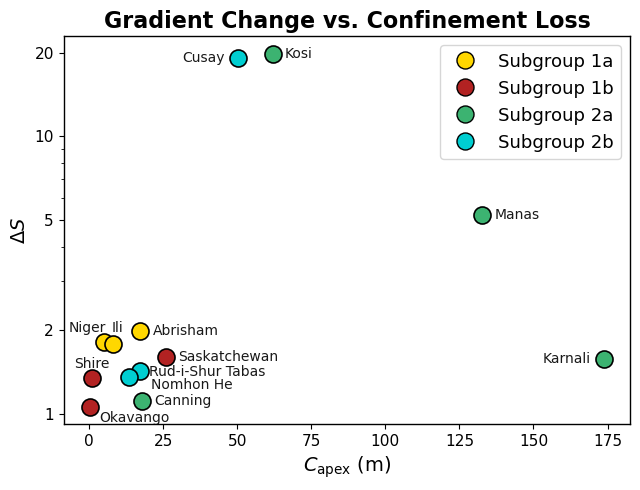

In [34]:
# =========================================================
# Fig. 3d: Gradient Ratio (ΔS) vs. Confinement Loss (C_apex)
# =========================================================

# --- 0. Helper Functions & Manual Offsets ---
def assign_all_subgroups(f):
    """Assigns fans to specific subgroups based on catchment/fan characteristics."""
    if f in ["Abrisham", "Ili", "Niger"]: return "Subgroup 1a"
    if f in ["Okavango", "Saskatchewan", "Shire"]: return "Subgroup 1b"
    if f in ["Canning", "Karnali", "Kosi", "Manas"]: return "Subgroup 2a"
    if f in ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]: return "Subgroup 2b"
    return np.nan

manual_offsets_3d = {
    "Cusay": {"px": -10, "py": 0},
    "Karnali": {"px": -10, "py": 0},
    "Nomhon He": {"px": 8, "py": -10},
    "Ili": {"px": 5, "py": 10},
    "Okavango": {"px": 7, "py": -8},
    "Rud-i-Shur Tabas": {"px": 15, "py": 4},
    "Shire": {"px": 0, "py": 10},
    "Niger": {"px": -5, "py": 12}, 
}

# --- 1. Data Prep: 3 km Reach-Averaged Confinement ---
conf_table = []
for fan_name in df2["Fan"].unique():
    # Sort by distance to ensure the upstream reach is chronological
    sub = df2[df2["Fan"] == fan_name].sort_values("Distance").reset_index(drop=True)
    
    # Locate apex
    apex_mask = sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])
    idx_list = sub.index[apex_mask].tolist()
    if not idx_list: continue
    
    apex_idx = idx_list[0]
    apex_dist = sub.loc[apex_idx, "Distance"]

    # Select nodes strictly within 3 km upstream of the apex
    # This logic averages the canyon depth leading into the fan
    pre_apex = sub[(sub["Distance"] < apex_dist) & (sub["Distance"] >= (apex_dist - 3))].copy()

    if not pre_apex.empty:
        # Reach-average calculation: Mean Topo Height - Mean River Height
        conf_loss = pre_apex["Mean Elevation"].mean() - pre_apex["River Elevation"].mean()
        conf_table.append({"Fan": fan_name, "C_apex_3km": conf_loss})

conf_df = pd.DataFrame(conf_table)

# --- 2. Data Integration ---
# Merge confinement with gradient ratios
plot_df = conf_df.merge(gradient_df[["Fan", "Gradient Ratio (Dr/Fn)"]], on="Fan", how="left")
plot_df = plot_df.rename(columns={"Gradient Ratio (Dr/Fn)": "delta_S"})

# Apply grouping and clean missing values
plot_df["Group"] = plot_df["Fan"].apply(assign_all_subgroups)
plot_df = plot_df.dropna(subset=["Group", "C_apex_3km", "delta_S"])
plot_df = plot_df[plot_df["delta_S"] > 0] # Ensure valid data for log scale

# --- 3. Figure Initialization ---
plt.close('all')
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=100)

# --- 4. Scatter Plotting ---
for g, col in colors.items():
    sub = plot_df[plot_df["Group"] == g]
    if sub.empty: continue
    
    ax.scatter(
        sub["C_apex_3km"], sub["delta_S"], 
        s=150, color=col, edgecolor="black", linewidth=1.2, zorder=3
    )

# --- 5. Labels (Point-Offset System) ---
for _, row in plot_df.iterrows():
    fan = row["Fan"]
    x, y = row["C_apex_3km"], row["delta_S"]

    # Retrieve manual nudge or default to 9pt right
    off = manual_offsets_3d.get(fan, {"px": 9, "py": 0})
    px, py = off.get("px", 9), off.get("py", 0)
    
    # Text alignment logic
    h_align = 'left' if px >= 0 else 'right'
    if px == 0: h_align = 'center'

    ax.text(
        x, y, fan, fontsize=10, ha=h_align, va='center', alpha=0.9,
        # Constant offset in 'points' regardless of data scale
        transform=transforms.offset_copy(ax.transData, fig=fig, x=px, y=py, units='points'),
        zorder=5
    )

# --- 6. Formatting & Aesthetics ---
ax.set_yscale("log") 
ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=14)
ax.set_ylabel(r"$\Delta S$", fontsize=14)
ax.set_title("Gradient Change vs. Confinement Loss", fontsize=16, fontweight='bold')

# Log-scale Y-axis formatting
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_yticks([1, 2, 5, 10, 20]) 
ax.tick_params(axis="both", labelsize=11)

# Legend Construction
handles = [
    mlines.Line2D([], [], color=colors[g], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label=g)
    for g in colors.keys() if g in plot_df["Group"].unique()
]
ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=13)

# Frame and Layout
for spine in ax.spines.values():
    spine.set_linewidth(1)
    
plt.tight_layout()
plt.show()

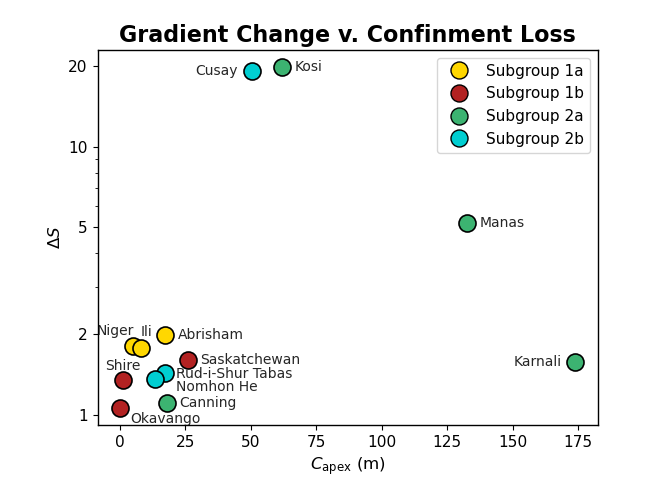

In [35]:
import matplotlib as mpl

# 1. Prevent the 'inline' backend from expanding the figure to fit labels
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

# 2. Set the DPI explicitly to match standard document sizes
mpl.rcParams['figure.dpi'] = 100

# --- 0. Grouping and Offsets ---
def assign_all_subgroups(f):
    if f in ["Abrisham", "Ili", "Niger"]: return "Subgroup 1a"
    if f in ["Okavango", "Saskatchewan", "Shire"]: return "Subgroup 1b"
    if f in ["Canning", "Karnali", "Kosi", "Manas"]: return "Subgroup 2a"
    if f in ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]: return "Subgroup 2b"
    return np.nan

manual_offsets_3d = {
    "Cusay": {"px": -10, "py": 0},
    "Karnali": {"px": -10, "py": 0},
    "Nomhon He": {"px": 8, "py": -10},
    "Ili": {"px": 5, "py": 10},
    "Okavango": {"px": 7, "py": -8},
    "Rud-i-Shur Tabas": {"px": 15, "py": 4},
    "Shire": {"px": 0, "py": 10},
    "Niger": {"px": -5, "py": 12}, 
}

# --- 1. Data Prep: 3 km Averaged Confinement ---
conf_table = []
for fan_name in df2["Fan"].unique():
    sub = df2[df2["Fan"] == fan_name].sort_values("Distance").reset_index(drop=True)
    
    apex_mask = sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])
    idx_list = sub.index[apex_mask].tolist()
    if not idx_list: continue
    
    apex_idx = idx_list[0]
    apex_dist = sub.loc[apex_idx, "Distance"]

    pre_apex = sub[(sub["Distance"] < apex_dist) & (sub["Distance"] >= (apex_dist - 3))].copy()

    if not pre_apex.empty:
        # 3-km average of topo - 3-km average of river
        conf_loss = pre_apex["Mean Elevation"].mean() - pre_apex["River Elevation"].mean()
        conf_table.append({"Fan": fan_name, "C_apex_mean": conf_loss})

conf_df = pd.DataFrame(conf_table)

# --- 2. Merge & Delta S Grouping ---
plot_df = conf_df.merge(gradient_df[["Fan", "Gradient Ratio (Dr/Fn)"]], on="Fan", how="left")
plot_df = plot_df.rename(columns={"Gradient Ratio (Dr/Fn)": "delta_S"})

plot_df["Group"] = plot_df["Fan"].apply(assign_all_subgroups)
plot_df = plot_df.dropna(subset=["Group", "C_apex_mean", "delta_S"])
plot_df = plot_df[plot_df["delta_S"] > 0] 

# --- 3. Figure Setup ---
fig, ax = plt.subplots(figsize=(6.5, 5))

# --- 4. Scatter Plotting ---
for group, color in colors.items():
    sub = plot_df[plot_df["Group"] == group]
    if sub.empty: continue
    
    ax.scatter(
        sub["C_apex_mean"], sub["delta_S"], 
        s=150, c=color, edgecolors="black", linewidths=1.2, zorder=3
    )

# --- 5. Labels ---
for _, row in plot_df.iterrows():
    fan = row["Fan"]
    x, y = row["C_apex_mean"], row["delta_S"]

    off = manual_offsets_3d.get(fan, {"px": 9, "py": 0})
    px, py = off.get("px", 9), off.get("py", 0)
    
    h_align = 'left' if px >= 0 else 'right'
    if px == 0: h_align = 'center'

    ax.text(
        x, y, fan, fontsize=10, ha=h_align, va='center', alpha=0.85,
        transform=transforms.offset_copy(ax.transData, fig=fig, x=px, y=py, units='points'),
        zorder=5
    )

# --- 6. Formatting ---
ax.set_yscale("log")
ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=12)
ax.set_ylabel(r"$\Delta S$", fontsize=12)
ax.set_title("Gradient Change v. Confinment Loss", fontsize=16, fontweight='bold')

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_yticks([1, 2, 5, 10, 20])
ax.tick_params(axis="both", labelsize=11)

handles = [
    mlines.Line2D([], [], color=colors[group], marker='o', linestyle='None',
                  markersize=np.sqrt(150), markeredgecolor='black', label=group)
    for group in colors.keys() if group in plot_df["Group"].unique()
]
ax.legend(handles=handles, fontsize=11, loc="upper right", frameon=True)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color("black")

plt.subplots_adjust(left=0.15, right=0.92, top=0.90, bottom=0.15)
plt.show()